In [1]:
from matplotlib.colors import BoundaryNorm, ListedColormap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from collections import defaultdict
from collections import Counter


def encode_overlap(A1: pd.DataFrame, A2: pd.DataFrame) -> pd.DataFrame:
    """
    Encode adjacency overlap:
    0 = missing both
    1 = only A1
    2 = only A2
    3 = both
    """
    return (A1 > 0).astype(int) + 2 * (A2 > 0).astype(int)


def extract_lag_block(adj: pd.DataFrame, lag: int) -> pd.DataFrame:
    """
    Extract (lag0, lagX) block from a big adjacency matrix.
    """
    rows = [c for c in adj.index if c.endswith(f"_lag0")]
    cols = [c for c in adj.columns if c.endswith(f"_lag{lag}")]
    return adj.loc[rows, cols]


def plot_lag_comparison_grid(
    A1_big: pd.DataFrame,
    A2_big: pd.DataFrame,
    lags: list[int],
):
    assert len(lags) == 8, "You must provide exactly 8 lags"

    fig, axes = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(20, 8),
        sharex=False,
        sharey=False,
    )

    cmap = ListedColormap(
        [
            "#f5f5f5",  # missing both
            "#5e81ac",  # only matrix 1
            "#e6c27a",  # only matrix 2
            "#66a61e",  # both
        ]
    )

    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    for i, lag in enumerate(lags):
        r = i // 4
        c = i % 4

        block1 = extract_lag_block(A1_big, lag)
        block2 = extract_lag_block(A2_big, lag)

        overlap = encode_overlap(block1, block2)

        ax = axes[r, c]
        sns.heatmap(
            overlap,
            ax=ax,
            cmap=cmap,
            norm=norm,
            cbar=False,
            square=True,
        )

        ax.set_title(f"Lag {lag}")

        # Remove all axis labels and ticks
        if c != 0:
            ax.set_yticks([])
        if r != 1:
            ax.set_xticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Legend
    handles = [
        plt.Line2D([0], [0], color="#f5f5f5", lw=6, label="Missing both"),
        plt.Line2D([0], [0], color="#5e81ac", lw=6, label="Only matrix TMFG-like"),
        plt.Line2D(
            [0], [0], color="#e6c27a", lw=6, label="Only matrix Min Clique Size 1"
        ),
        plt.Line2D([0], [0], color="#66a61e", lw=6, label="Both"),
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        frameon=False,
    )

    plt.tight_layout()
    plt.show()


def plot_adjacency_overlap_heatmap(presence_df: pd.DataFrame):
    """
    Plot categorical heatmap of adjacency overlap.
    """

    cmap = ListedColormap(
        [
            "white",  # 0: missing in both
            "blue",  # 1: only A1
            "yellow",  # 2: only A2
            "green",  # 3: both
        ]
    )

    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, ax = plt.subplots(figsize=(8, 8))

    im = ax.imshow(presence_df.values, cmap=cmap, norm=norm)

    ax.set_title("Adjacency Matrix Overlap")
    ax.set_xlabel("Nodes")
    ax.set_ylabel("Nodes")

    ax.set_xticks([])
    ax.set_yticks([])

    # Custom legend
    legend_labels = [
        ("Missing in both", "white"),
        ("Only matrix 1", "blue"),
        ("Only matrix 2", "yellow"),
        ("In both", "green"),
    ]

    handles = [
        plt.Line2D(
            [0], [0], marker="s", color="w", markerfacecolor=color, markersize=12
        )
        for _, color in legend_labels
    ]

    ax.legend(
        handles,
        [label for label, _ in legend_labels],
        loc="upper right",
        frameon=False,
    )

    plt.tight_layout()
    plt.show()


def adjacency_presence_matrix(A1: pd.DataFrame, A2: pd.DataFrame) -> pd.DataFrame:
    """
    Compare two unweighted adjacency matrices.

    Returns a DataFrame with values:
        0 = missing in both
        1 = only in A1
        2 = only in A2
        3 = in both
    """

    # Ensure same ordering
    assert A1.index.equals(A2.index)
    assert A1.columns.equals(A2.columns)

    B1 = (A1.values != 0).astype(int)
    B2 = (A2.values != 0).astype(int)

    presence = (
        ((B1 == 1) & (B2 == 1)) * 3
        + ((B1 == 1) & (B2 == 0)) * 1
        + ((B1 == 0) & (B2 == 1)) * 2
    )

    return pd.DataFrame(presence, index=A1.index, columns=A1.columns)


def get_equispaced_indices(total=106, n=16):
    """
    Return n equispaced integers between 1 and total (inclusive).
    """
    import numpy as np

    # linspace gives floats → round → convert to int → ensure uniqueness
    idx = np.linspace(1, total, n)
    idx = np.unique(idx.round().astype(int))
    return idx.tolist()


def plot_conditional_adjacency_matrices(df, n_plots_to_view=16):
    lags = sorted(
        list(set([int(c.split("_lag")[1]) for c in df.columns])), reverse=True
    )
    subblocks_number = len(lags)

    n_features = 20
    size = df.shape[0]

    indices = get_equispaced_indices(total=subblocks_number, n=n_plots_to_view)

    # add to indices the first ten and last ten lags if not already present
    for i in range(1, 11):
        if i not in indices:
            indices.append(i)
    for i in range(subblocks_number - 9, subblocks_number + 1):
        if i not in indices:
            indices.append(i)

    fig, axs = plt.subplots(8, 4, figsize=(20, 40))
    current_plot = 0
    for i, lag in enumerate(lags):
        if i + 1 not in indices:
            continue

        row = current_plot // 4
        col = current_plot % 4
        subblock = df.iloc[
            size - n_features : size, i * n_features : (i + 1) * n_features
        ]
        sns.heatmap(subblock, ax=axs[row, col], cbar=False, cmap="viridis")
        axs[row, col].set_title(f"Lag {lag}", fontsize=30)
        current_plot += 1
        # if not last row, remove x ticks
        if row < 7:
            axs[row, col].set_xticks([])
        # if not first column, remove y ticks
        if col > 0:
            axs[row, col].set_yticks([])
    plt.tight_layout()
    plt.show()


def plot_conditional_adjacency_matrices_brief(df, indices):
    lags = sorted(
        list(set([int(c.split("_lag")[1]) for c in df.columns])), reverse=True
    )

    n_features = 20
    size = df.shape[0]

    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    current_plot = 0
    for i, lag in enumerate(lags):
        if i + 1 not in indices:
            continue

        row = current_plot // 4
        col = current_plot % 4
        subblock = df.iloc[
            size - n_features : size, i * n_features : (i + 1) * n_features
        ]
        sns.heatmap(subblock, ax=axs[row, col], cbar=False, cmap="viridis")
        axs[row, col].set_title(f"Lag {lag}", fontsize=18)
        current_plot += 1
        # if not last row, remove x ticks
        if row < 1:
            axs[row, col].set_xticks([])
        # if not first column, remove y ticks
        if col > 0:
            axs[row, col].set_yticks([])
    plt.tight_layout()
    plt.show()


def count_all_cliques(adj_df):
    """
    Count how many cliques of every size exist in an undirected graph.
    Returns a dict: {clique_size: count}.
    """
    G = nx.from_numpy_array(adj_df.values)

    clique_count = defaultdict(int)

    # enumerate_all_cliques returns cliques of size 1,2,3,... in increasing order
    for clique in nx.enumerate_all_cliques(G):
        clique_size = len(clique)
        clique_count[clique_size] += 1

    return dict(clique_count)


def consecutive_survival_distribution(matrices):
    """
    Given a list of boolean adjacency matrices ordered by lag,
    returns a distribution of consecutive survival lengths across all elements.
    """
    mats = [np.asarray(M, dtype=bool) for M in matrices]
    stack = np.stack(mats, axis=0)  # shape = (L, N, N)

    L = stack.shape[0]
    N = stack.shape[1]

    all_streaks = []

    # Iterate over each element (i,j)
    for i in range(N):
        for j in range(N):
            s = stack[:, i, j]  # boolean sequence across lags

            streak = 0
            for t in range(L):
                if s[t]:
                    streak += 1
                else:
                    if streak > 0:
                        all_streaks.append(streak)
                        streak = 0
            # end-of-sequence streak
            if streak > 0:
                all_streaks.append(streak)

    # Generate distribution
    distribution = Counter(all_streaks)

    return dict(distribution)


def get_subblocks_from_adjacency_matrix(adj_matrix, n_lags, n_features):
    """
    Given a large adjacency matrix that encodes spatiotemporal relationships,
    extract subblocks corresponding to each lag.
    Returns a list of subblocks.
    """
    size = adj_matrix.shape[0]
    lag_subblock_map = {}

    col_start = size - n_features
    col_end = size

    for lag in range(n_lags):
        row_start = lag * n_features
        row_end = (lag + 1) * n_features

        subblock = adj_matrix[row_start:row_end, col_start:col_end]
        lag_subblock_map[lag] = subblock

    return lag_subblock_map


def plot_survival_distribution(df):
    lags = sorted(
        list(set([int(c.split("_lag")[1]) for c in df.columns])), reverse=True
    )

    lag_subblock_map = get_subblocks_from_adjacency_matrix(
        df.values, n_lags=len(lags), n_features=20
    )
    survival_distribution = consecutive_survival_distribution(
        [lag_subblock_map[lag] for lag in range(100)]
    )
    # plot survival distribution
    plt.figure(figsize=(10, 6))
    plt.bar(
        survival_distribution.keys(), survival_distribution.values(), color="skyblue"
    )
    plt.xlabel("Consecutive Survival Length")
    plt.ylabel("Frequency")
    plt.title("Consecutive Survival Distribution Across Lags")

    # print on the plot the mean consecutive survival length
    total_length = sum(
        length * count for length, count in survival_distribution.items()
    )
    total_count = sum(survival_distribution.values())
    mean_length = total_length / total_count if total_count > 0 else 0
    plt.axvline(mean_length, color="red", linestyle="--", label="Mean Length")
    plt.legend()
    plt.show()


def edges_for_lag(adj: pd.DataFrame, lag: int) -> set[tuple[str, str]]:
    """
    Extract edges connecting lag0 ↔ lagX for a given lag.
    """
    lag0_nodes = [n for n in adj.index if n.endswith("_lag0")]
    lagX_nodes = [n for n in adj.index if n.endswith(f"_lag{lag}")]

    edges = set()
    sub = adj.loc[lag0_nodes, lagX_nodes]

    for i in lag0_nodes:
        for j in lagX_nodes:
            if sub.loc[i, j] != 0:
                edges.add((i, j))

    return edges


def overlap_counts_per_lag(
    A1: pd.DataFrame,
    A2: pd.DataFrame,
    A3: pd.DataFrame,
    lags: list[int],
) -> pd.DataFrame:

    rows = []

    for lag in lags:
        E1 = edges_for_lag(A1, lag)
        E2 = edges_for_lag(A2, lag)
        E3 = edges_for_lag(A3, lag)

        only0 = E1 - E2 - E3
        only1 = E2 - E1 - E3
        only2 = E3 - E1 - E2
        only01 = (E1 & E2) - E3
        only02 = (E1 & E3) - E2
        only12 = (E2 & E3) - E1
        only012 = E1 & E2 & E3

        rows.extend(
            [
                {"lag": lag, "category": "only0", "count": len(only0)},
                {"lag": lag, "category": "only1", "count": len(only1)},
                {"lag": lag, "category": "only2", "count": len(only2)},
                {"lag": lag, "category": "only01", "count": len(only01)},
                {"lag": lag, "category": "only02", "count": len(only02)},
                {"lag": lag, "category": "only12", "count": len(only12)},
                {"lag": lag, "category": "only012", "count": len(only012)},
                {"lag": lag, "category": "total", "count": len(E1 | E2 | E3)},
            ]
        )

    return pd.DataFrame(rows)


def plot_overlap_dynamics(df):
    COLOR_MAP = {
        # Primary (RYB)
        "only0": "#d62728",  # Red
        "only1": "#ffbf00",  # Yellow (not neon)
        "only2": "#1f77b4",  # Blue
        # Secondary (RYB mixes)
        "only01": "#ff7f0e",  # Orange (Red + Yellow)
        "only12": "#2ca02c",  # Green (Yellow + Blue)
        "only02": "#9467bd",  # Purple (Red + Blue)
        # Tertiary
        "only012": "#8c564b",  # Brown
        # Union
        "total": "#000000",  # Black
    }

    STYLE_MAP = {
        "only0": "solid",
        "only1": "solid",
        "only2": "solid",
        "only01": "dashed",
        "only02": "dashed",
        "only12": "dashed",
        "only012": "dashdot",
        "total": (0, (1, 1)),  # dotted, visually distinct
    }

    fig, (ax_top, ax_bottom) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # -------------------------
    # TOP: all except "total"
    # -------------------------
    for category, sub in df.groupby("category"):
        if category == "total":
            continue

        ax_top.plot(
            sub["lag"],
            sub["count"],
            label=category,
            color=COLOR_MAP[category],
            linestyle=STYLE_MAP[category],
            linewidth=2,
            alpha=0.85,
        )

    ax_top.set_ylabel("Number of edges")
    ax_top.set_title("Edge overlap dynamics across lags")
    ax_top.grid(True, which="both", linestyle="--", alpha=0.4)

    ax_top.legend(
        title="Edge category",
        ncol=2,
        frameon=True,
    )
    ax_top.set_xlim(0, df["lag"].max())

    # -------------------------
    # BOTTOM: only "total"
    # -------------------------
    total_df = df[df["category"] == "total"]

    ax_bottom.plot(
        total_df["lag"],
        total_df["count"],
        label="total",
        color=COLOR_MAP["total"],
        linewidth=3,
    )
    ax_bottom.set_xlim(0, df["lag"].max())

    ax_bottom.set_xlabel("Lag")
    ax_bottom.set_ylabel("Total edges")
    ax_bottom.grid(True, which="both", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


path = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix/final_adjacency_matrix.tsv"
path0 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix/conditional_adjacency_matrix_class_0.tsv"
path1 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix/conditional_adjacency_matrix_class_1.tsv"
path2 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix/conditional_adjacency_matrix_class_2.tsv"

In [2]:
df_final = pd.read_csv(path, sep="\t", index_col=0)
df0 = pd.read_csv(path0, sep="\t", index_col=0)
df1 = pd.read_csv(path1, sep="\t", index_col=0)
df2 = pd.read_csv(path2, sep="\t", index_col=0)
df_final.head()

,ASKs1_lag300,BIDs1_lag300,ASKs2_lag300,BIDs2_lag300,ASKs3_lag300,BIDs3_lag300,ASKs4_lag300,BIDs4_lag300,ASKs5_lag300,BIDs5_lag300,...,ASKs6_lag0,BIDs6_lag0,ASKs7_lag0,BIDs7_lag0,ASKs8_lag0,BIDs8_lag0,ASKs9_lag0,BIDs9_lag0,ASKs10_lag0,BIDs10_lag0
ASKs1_lag300,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BIDs1_lag300,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ASKs2_lag300,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
BIDs2_lag300,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ASKs3_lag300,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


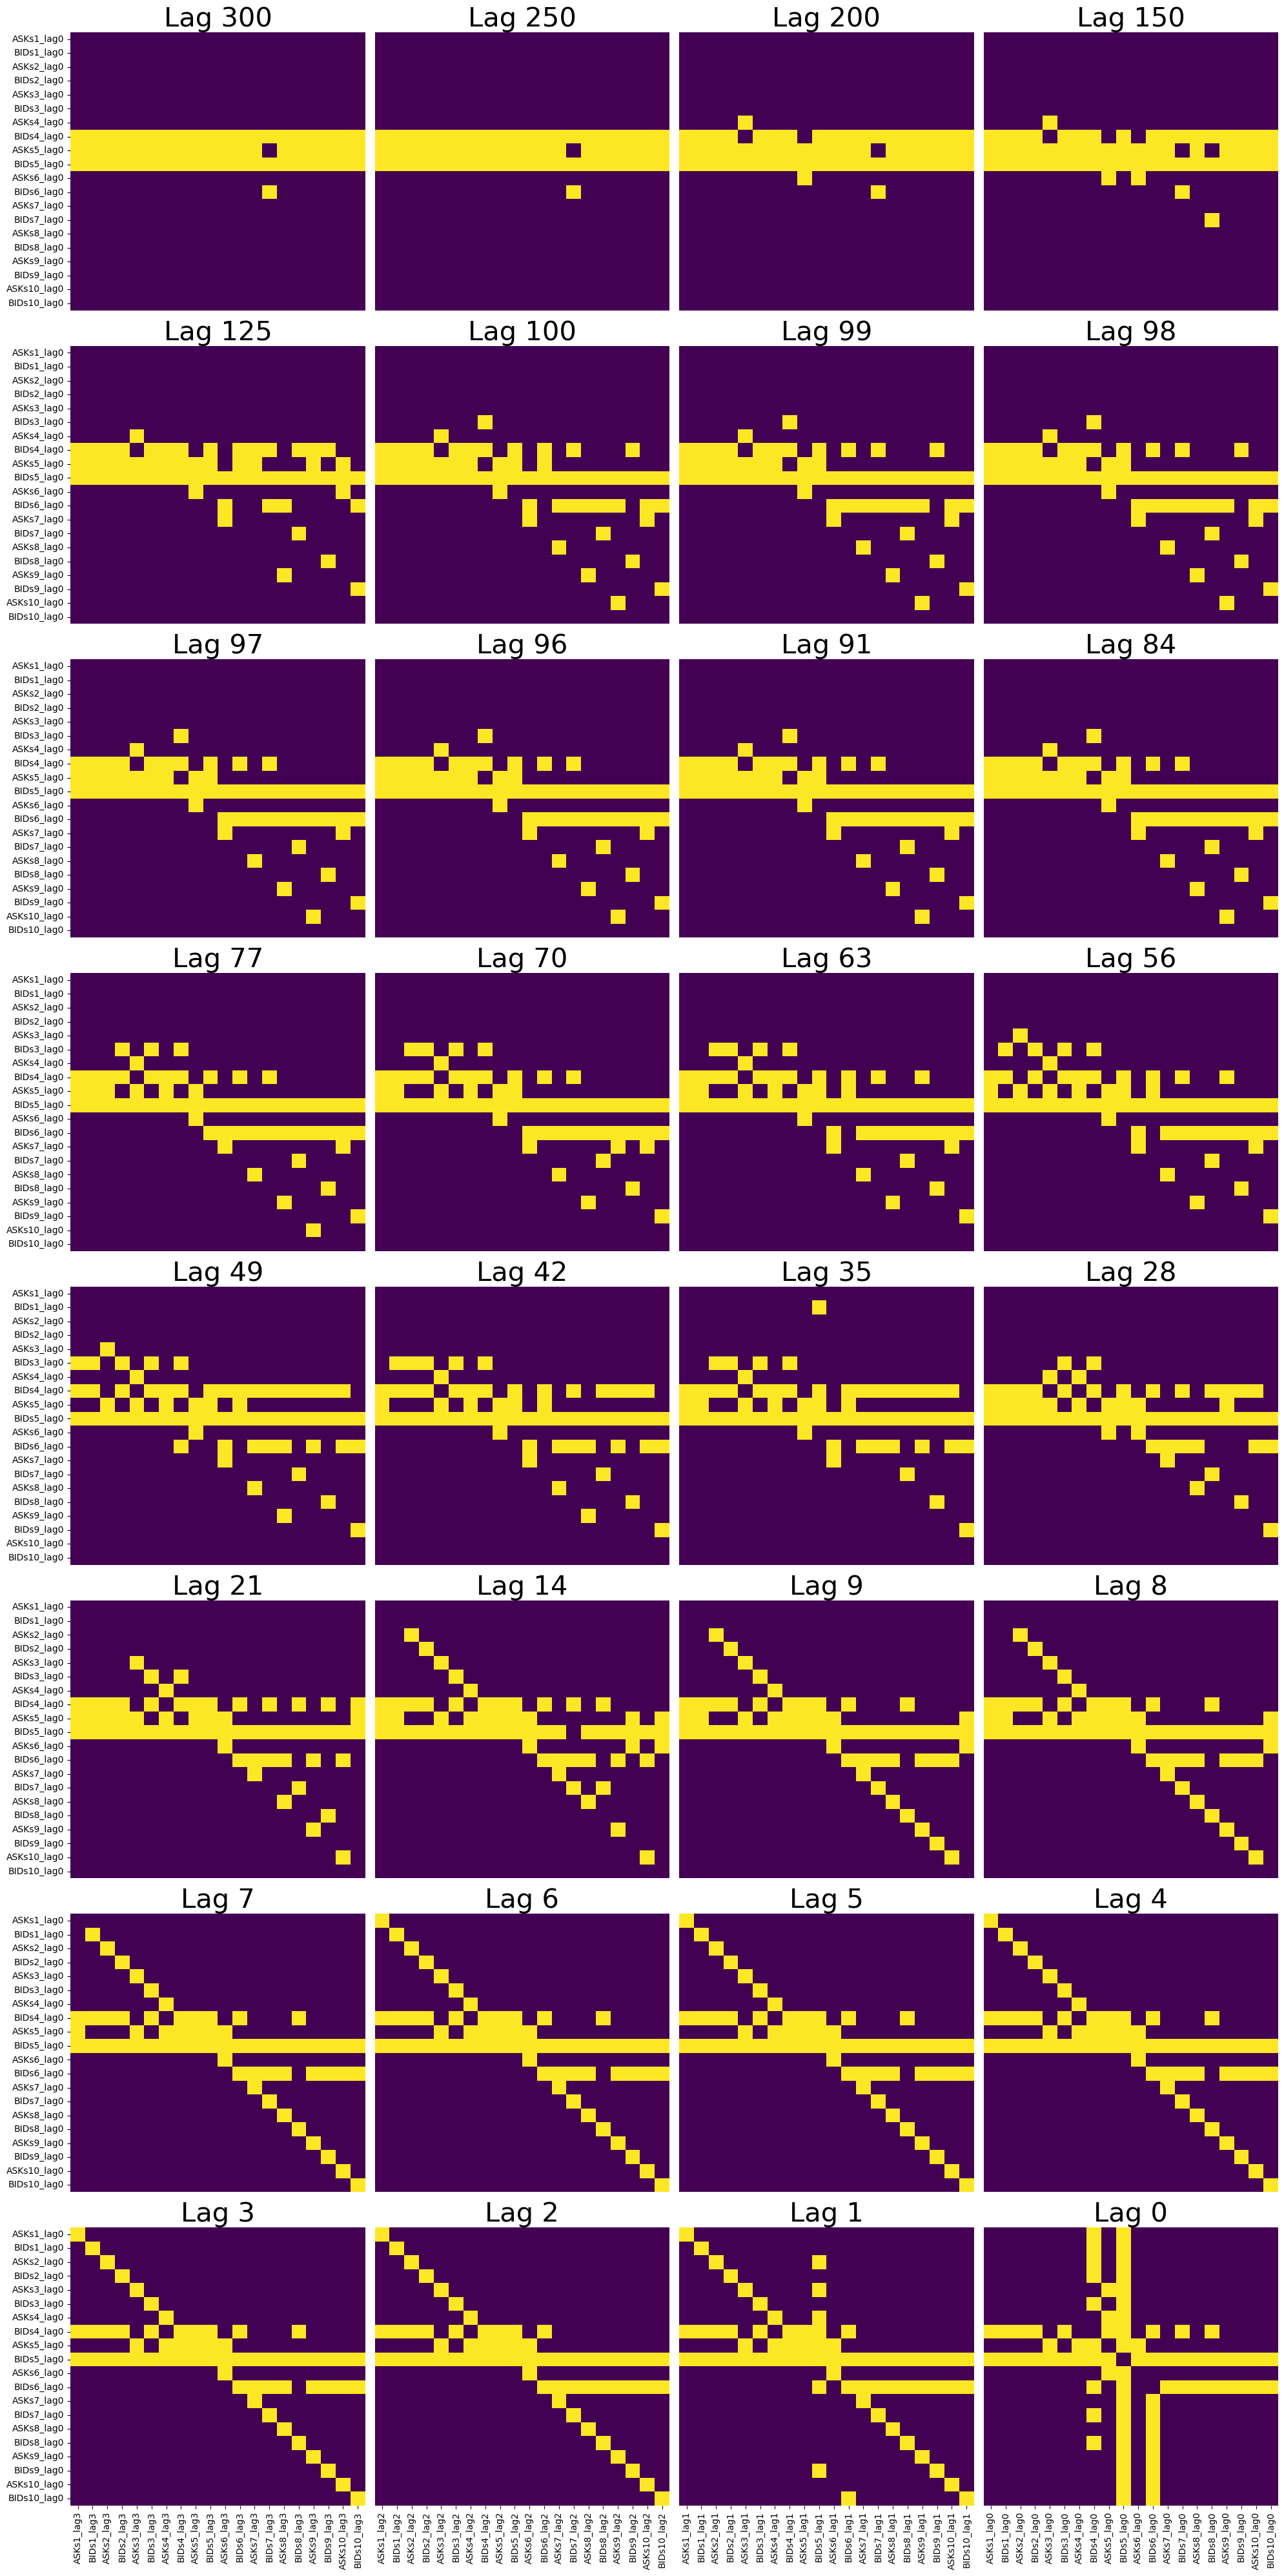

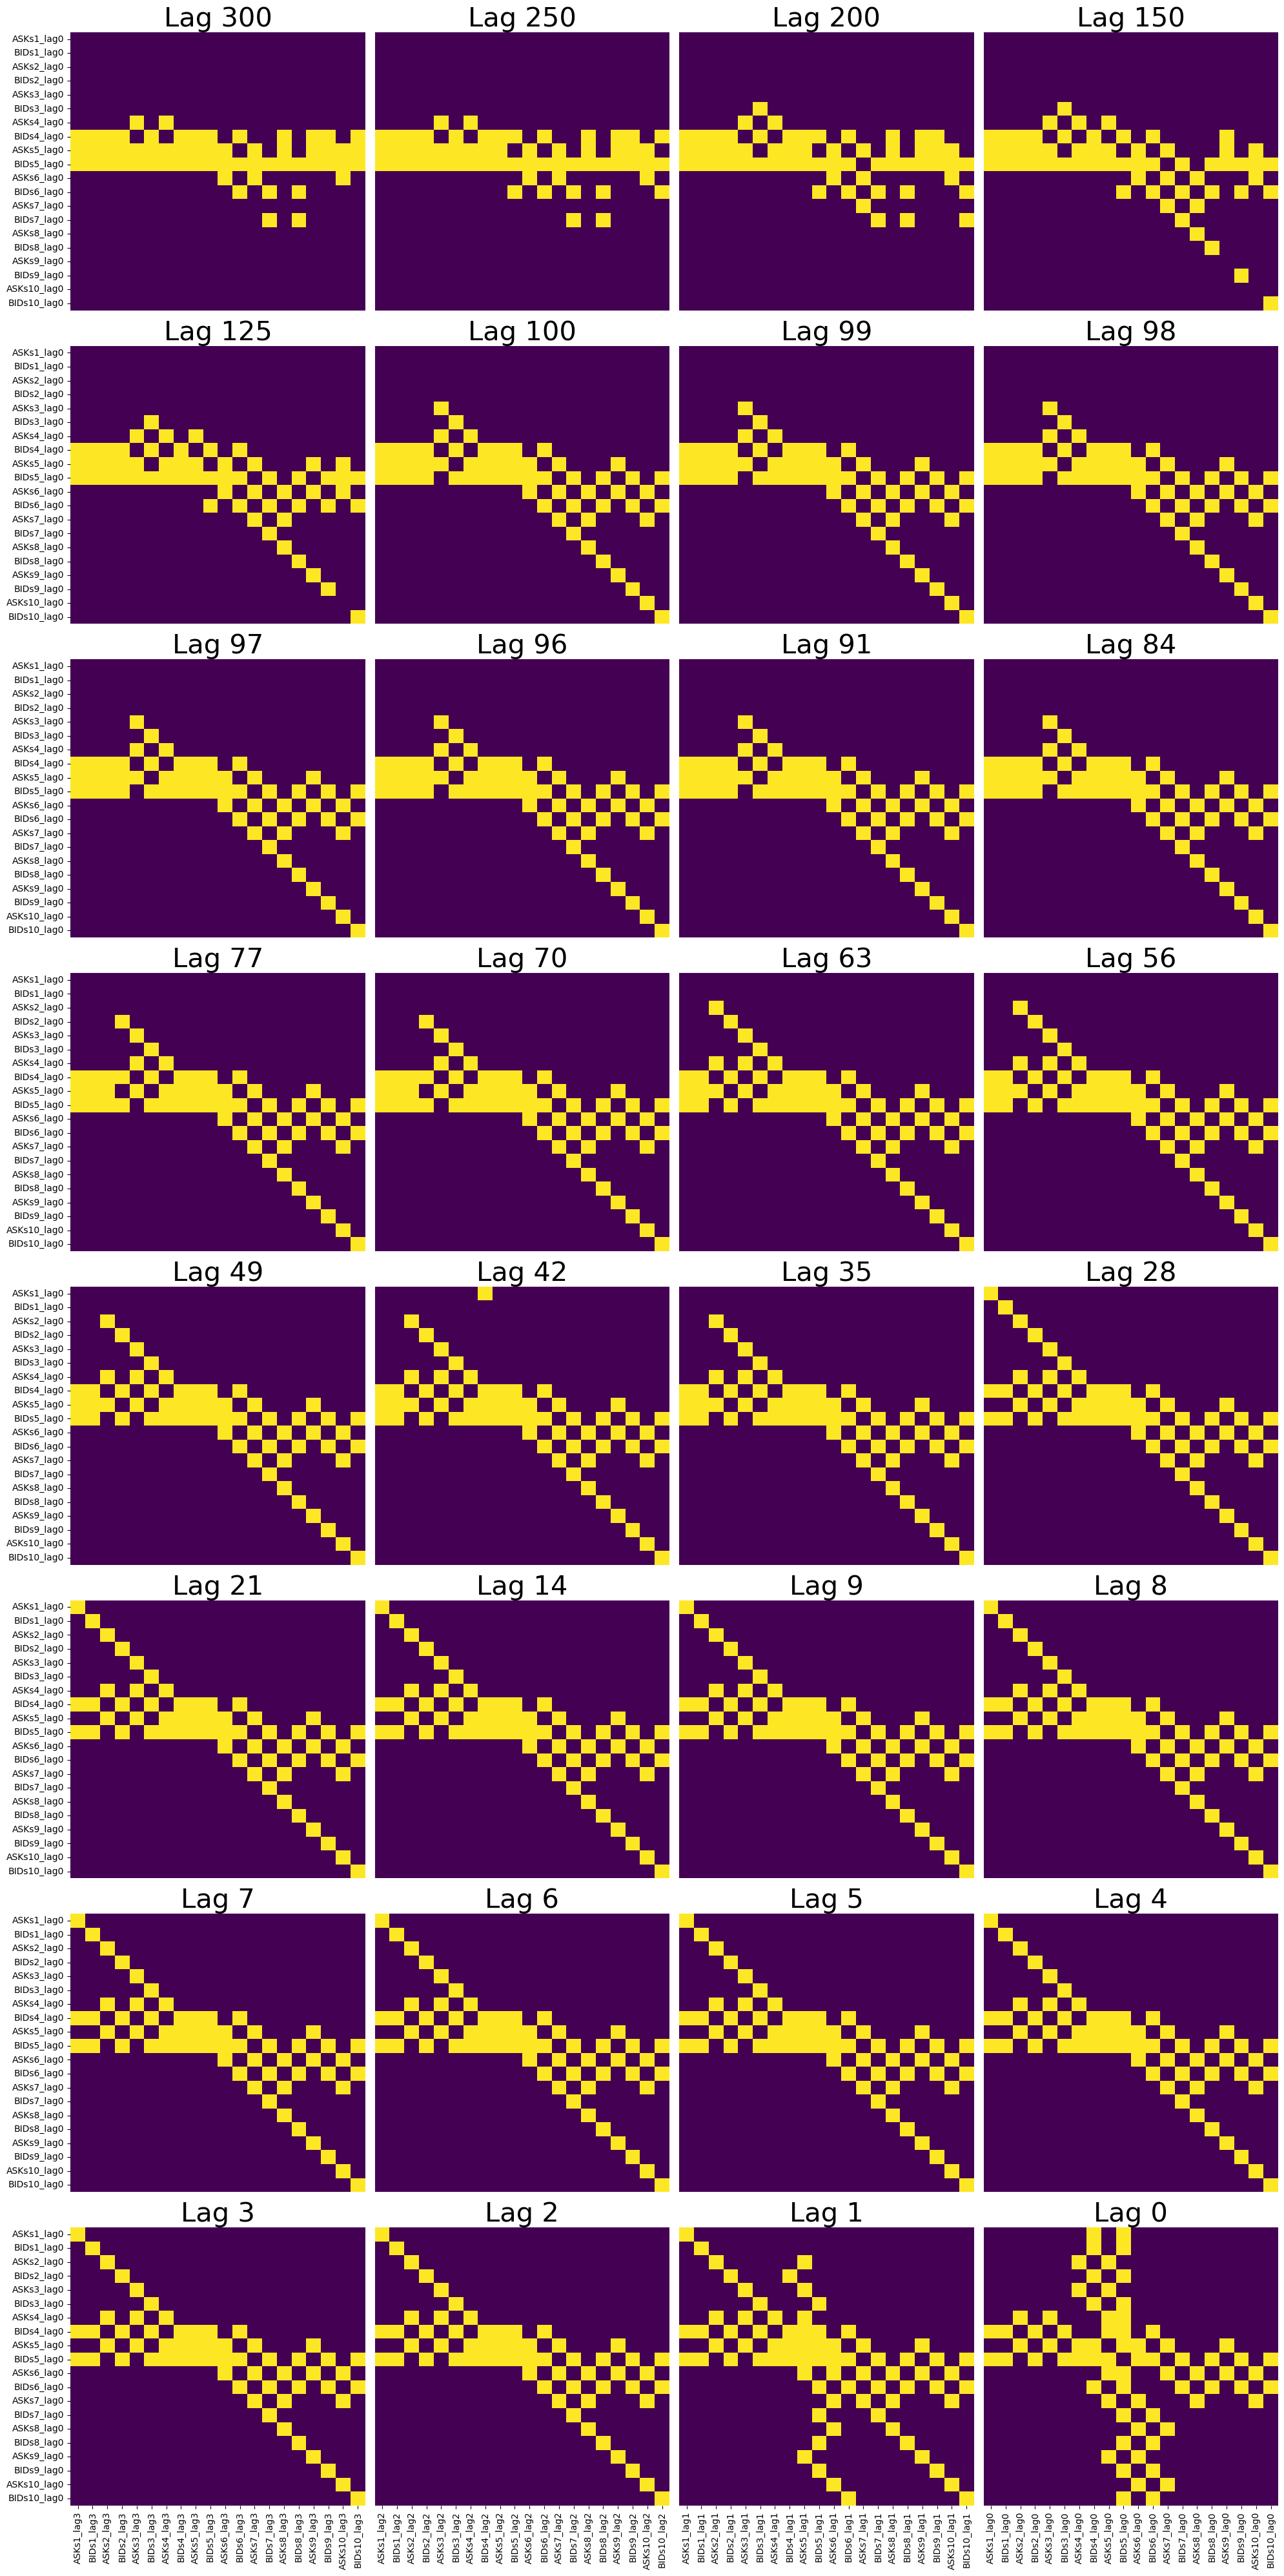

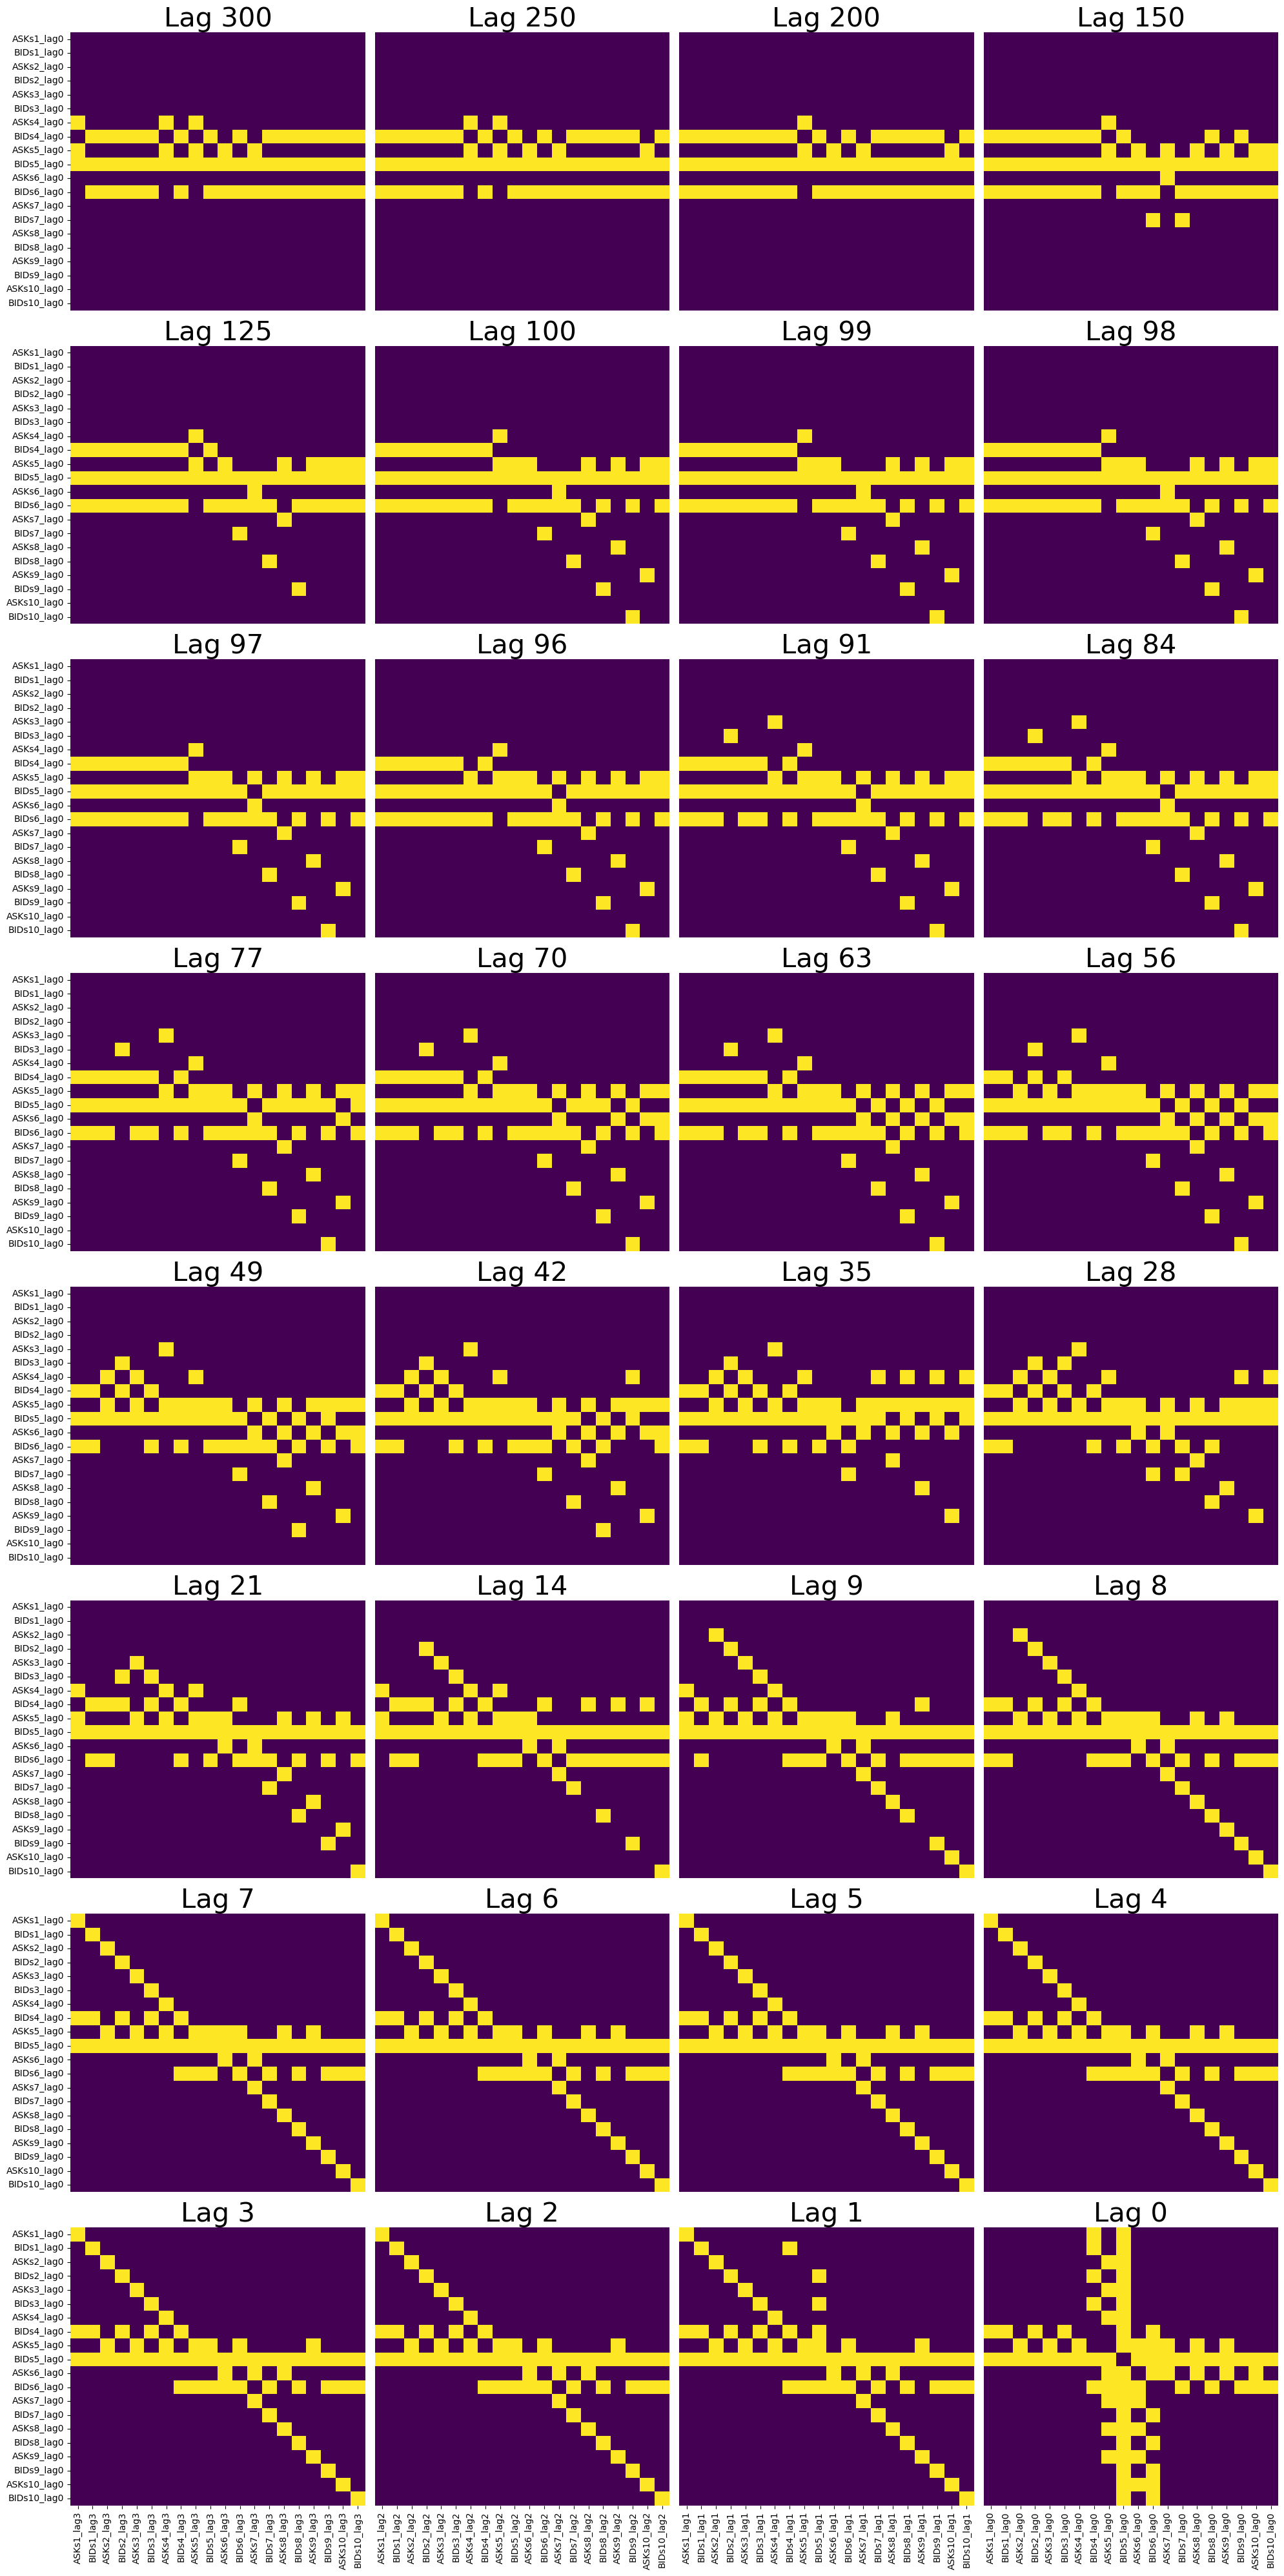

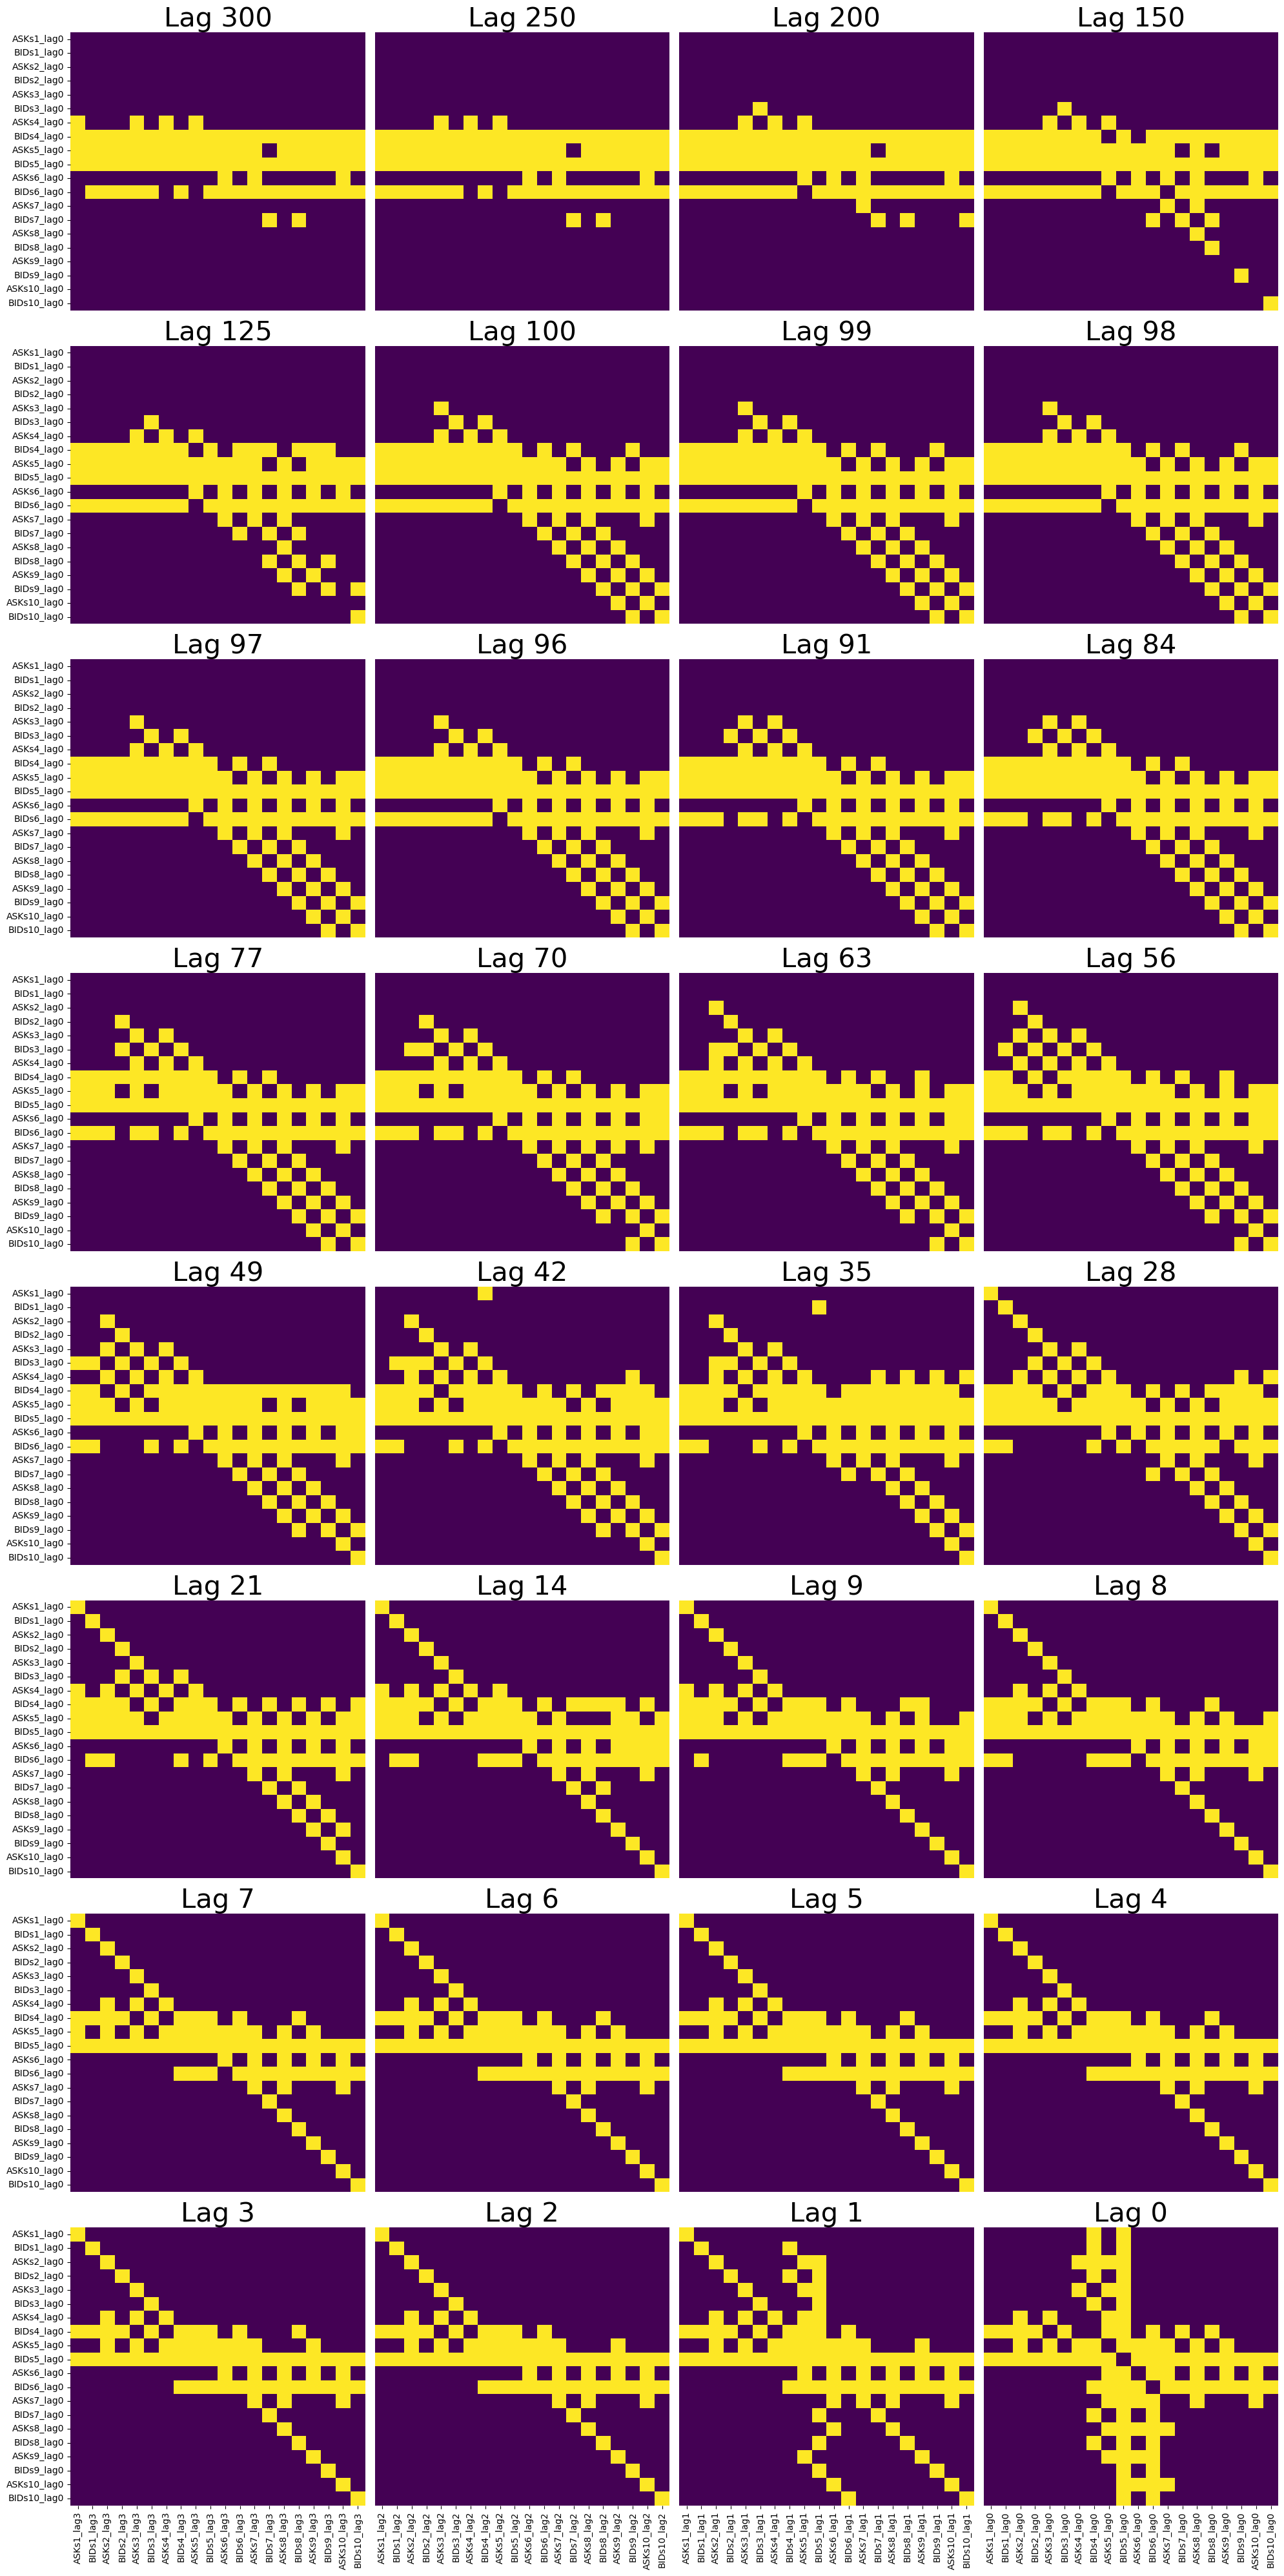

In [3]:
plot_conditional_adjacency_matrices(df0)
plot_conditional_adjacency_matrices(df1)
plot_conditional_adjacency_matrices(df2)
plot_conditional_adjacency_matrices(df_final)

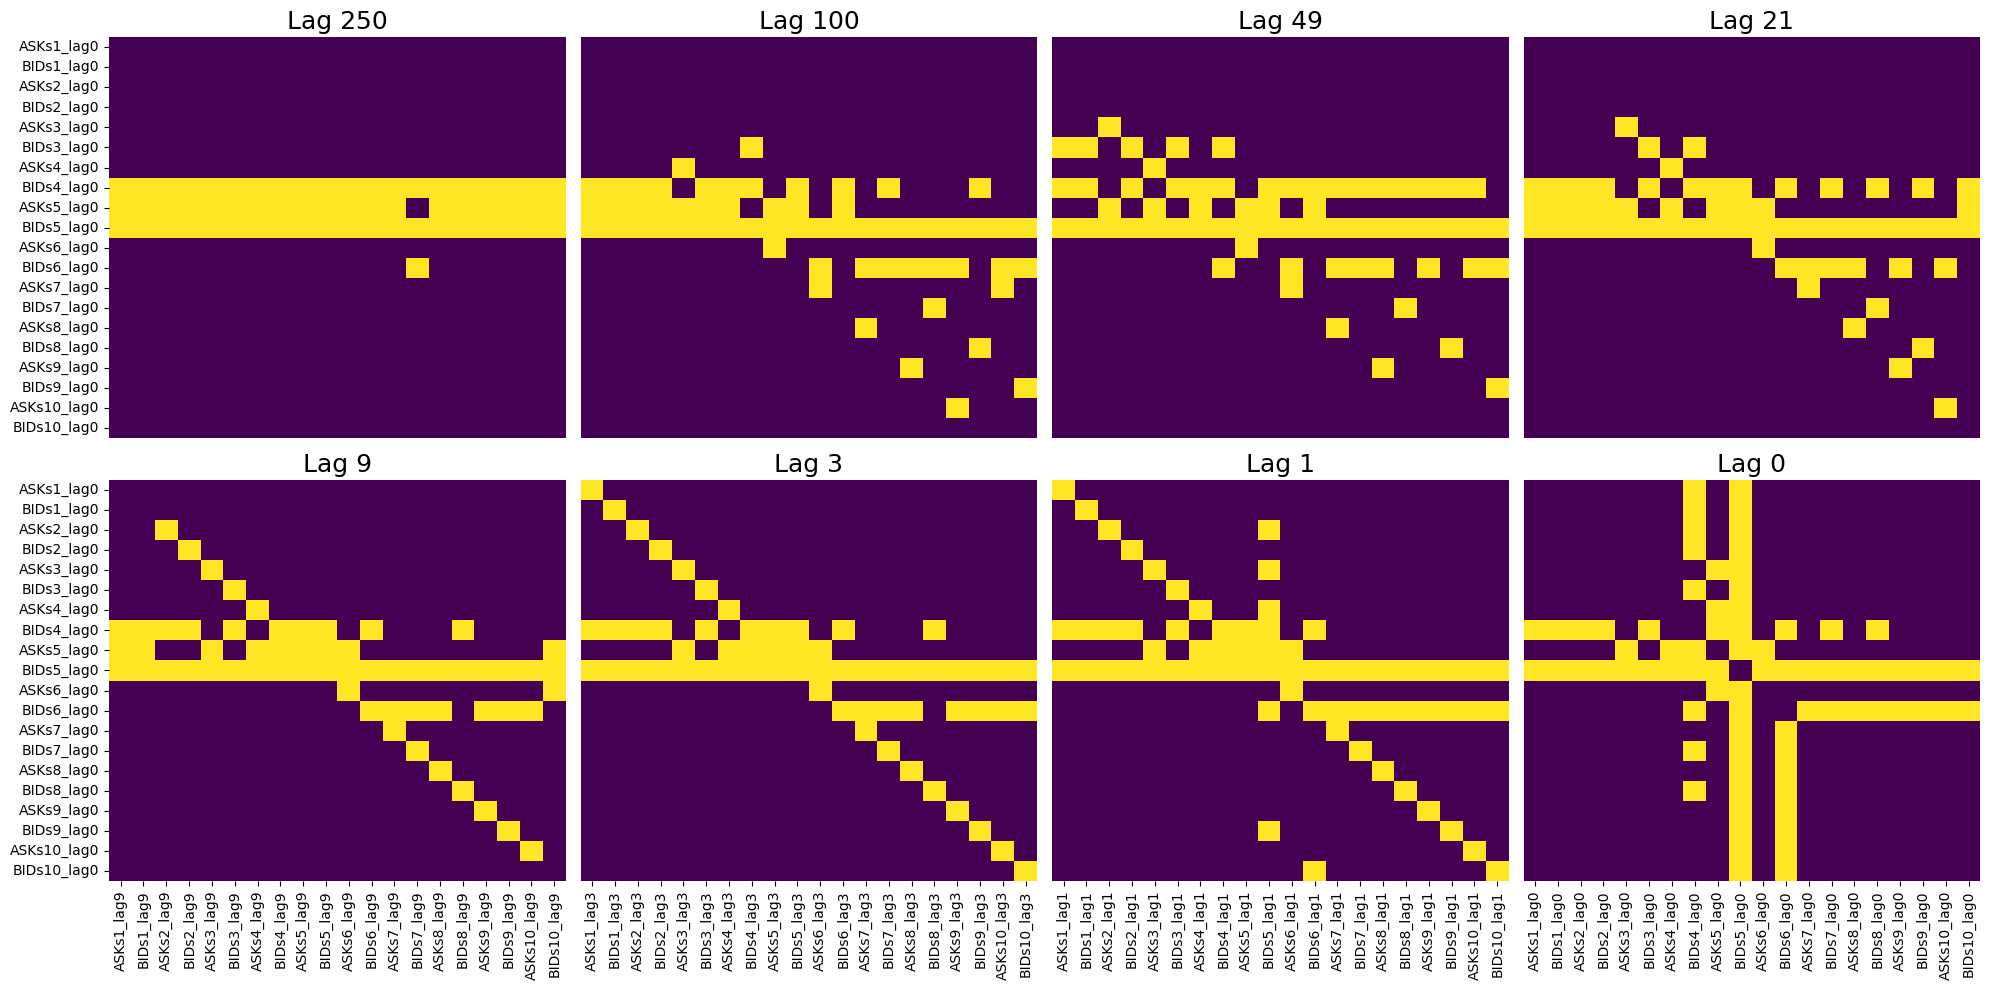

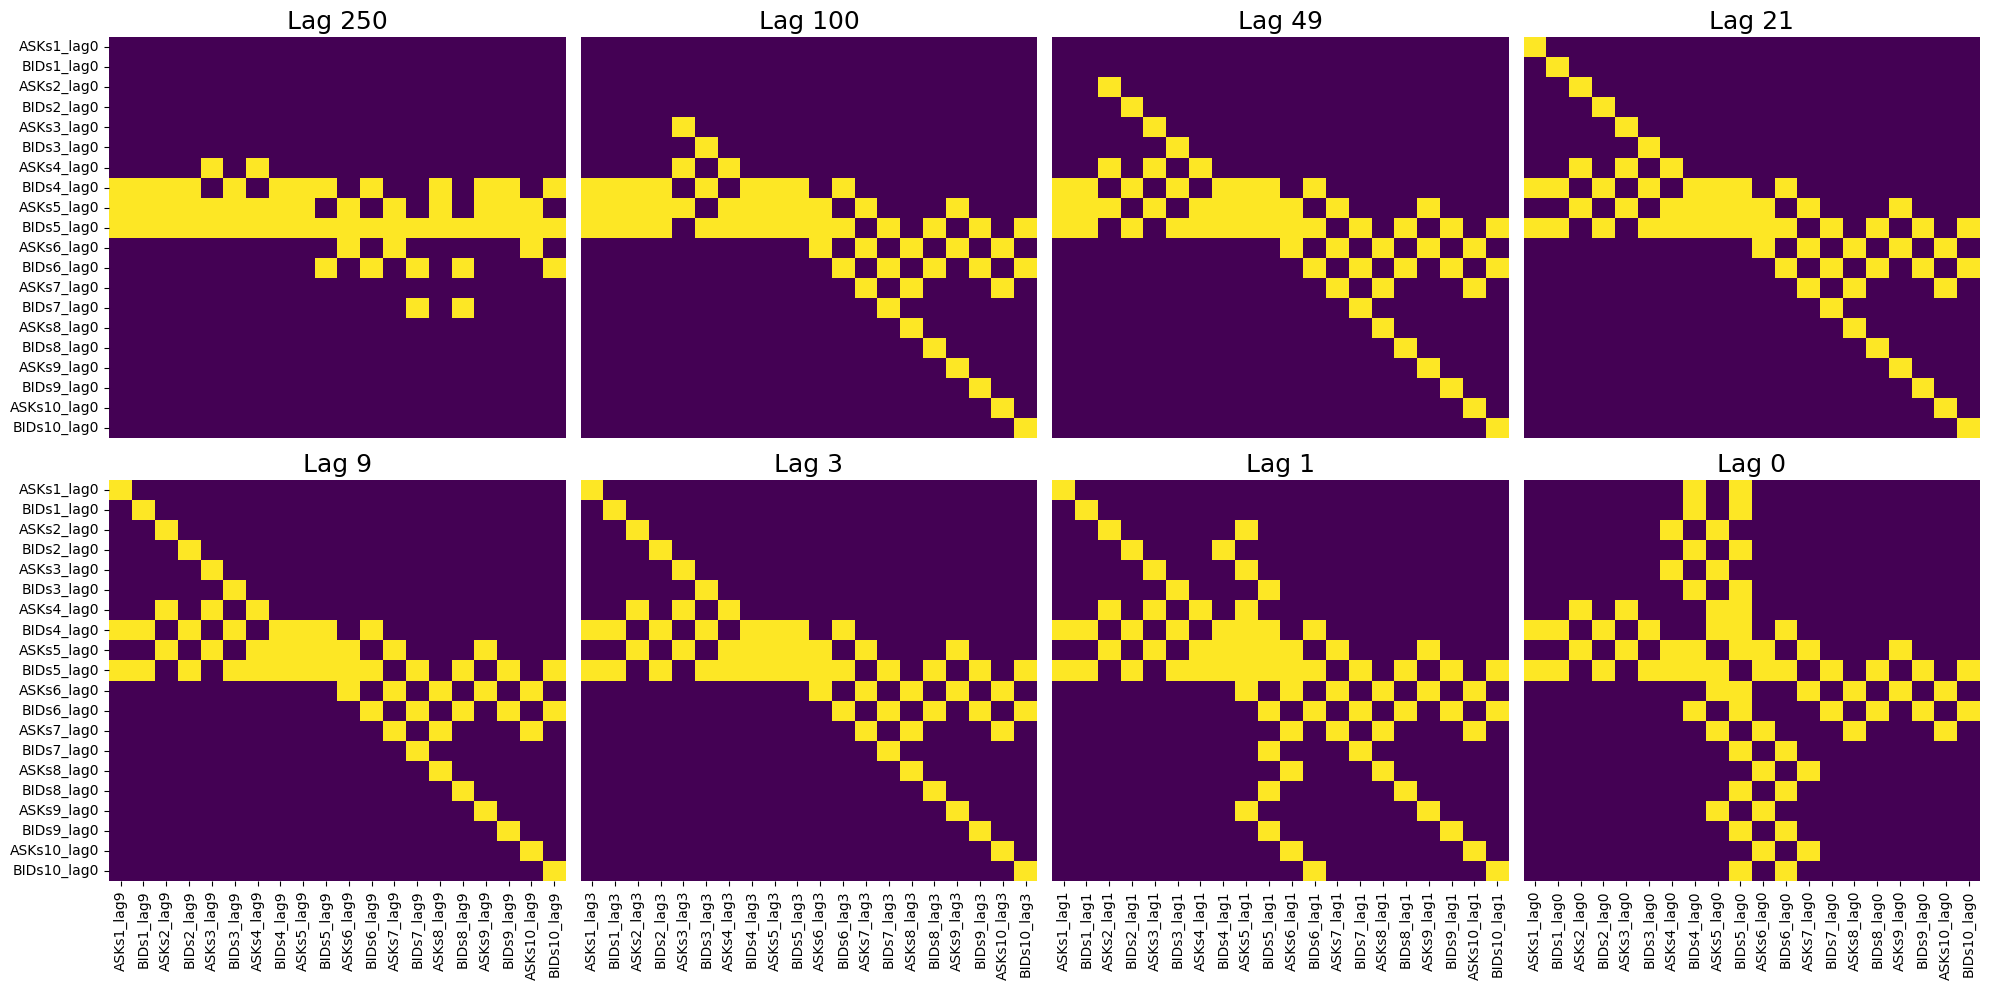

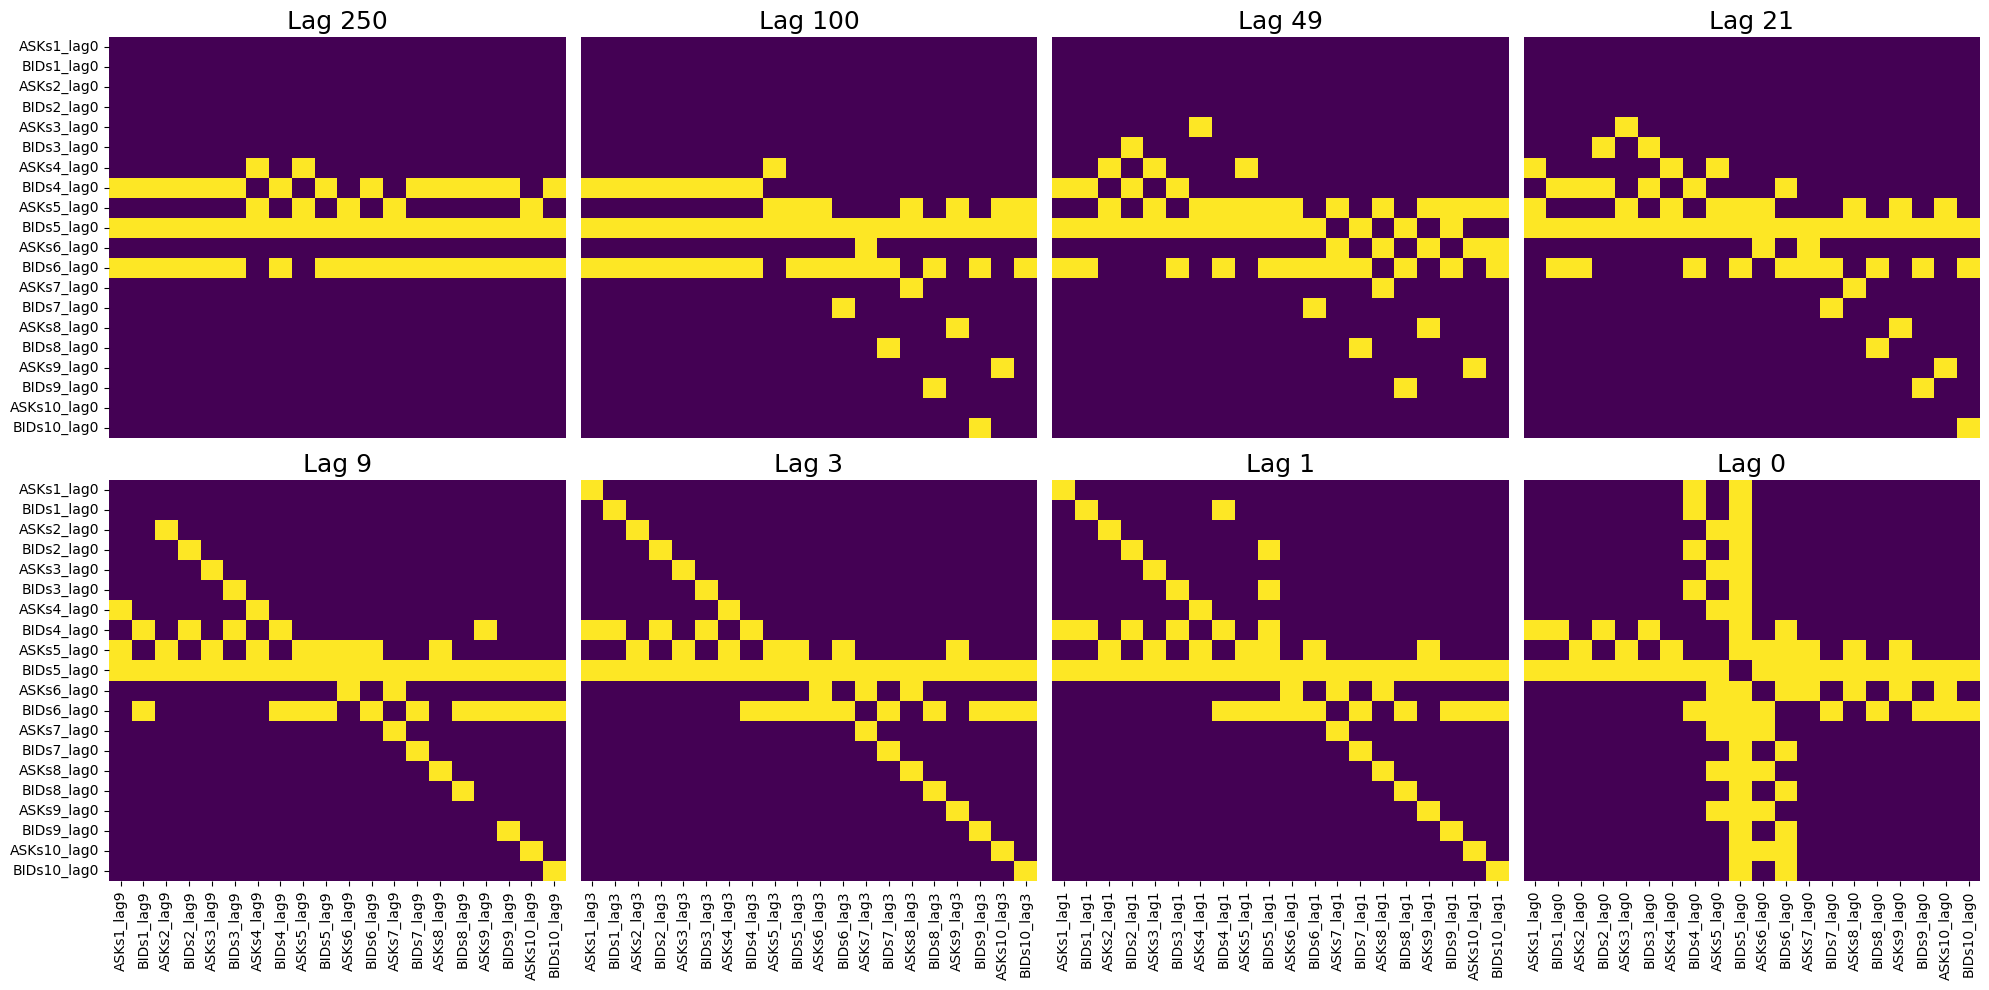

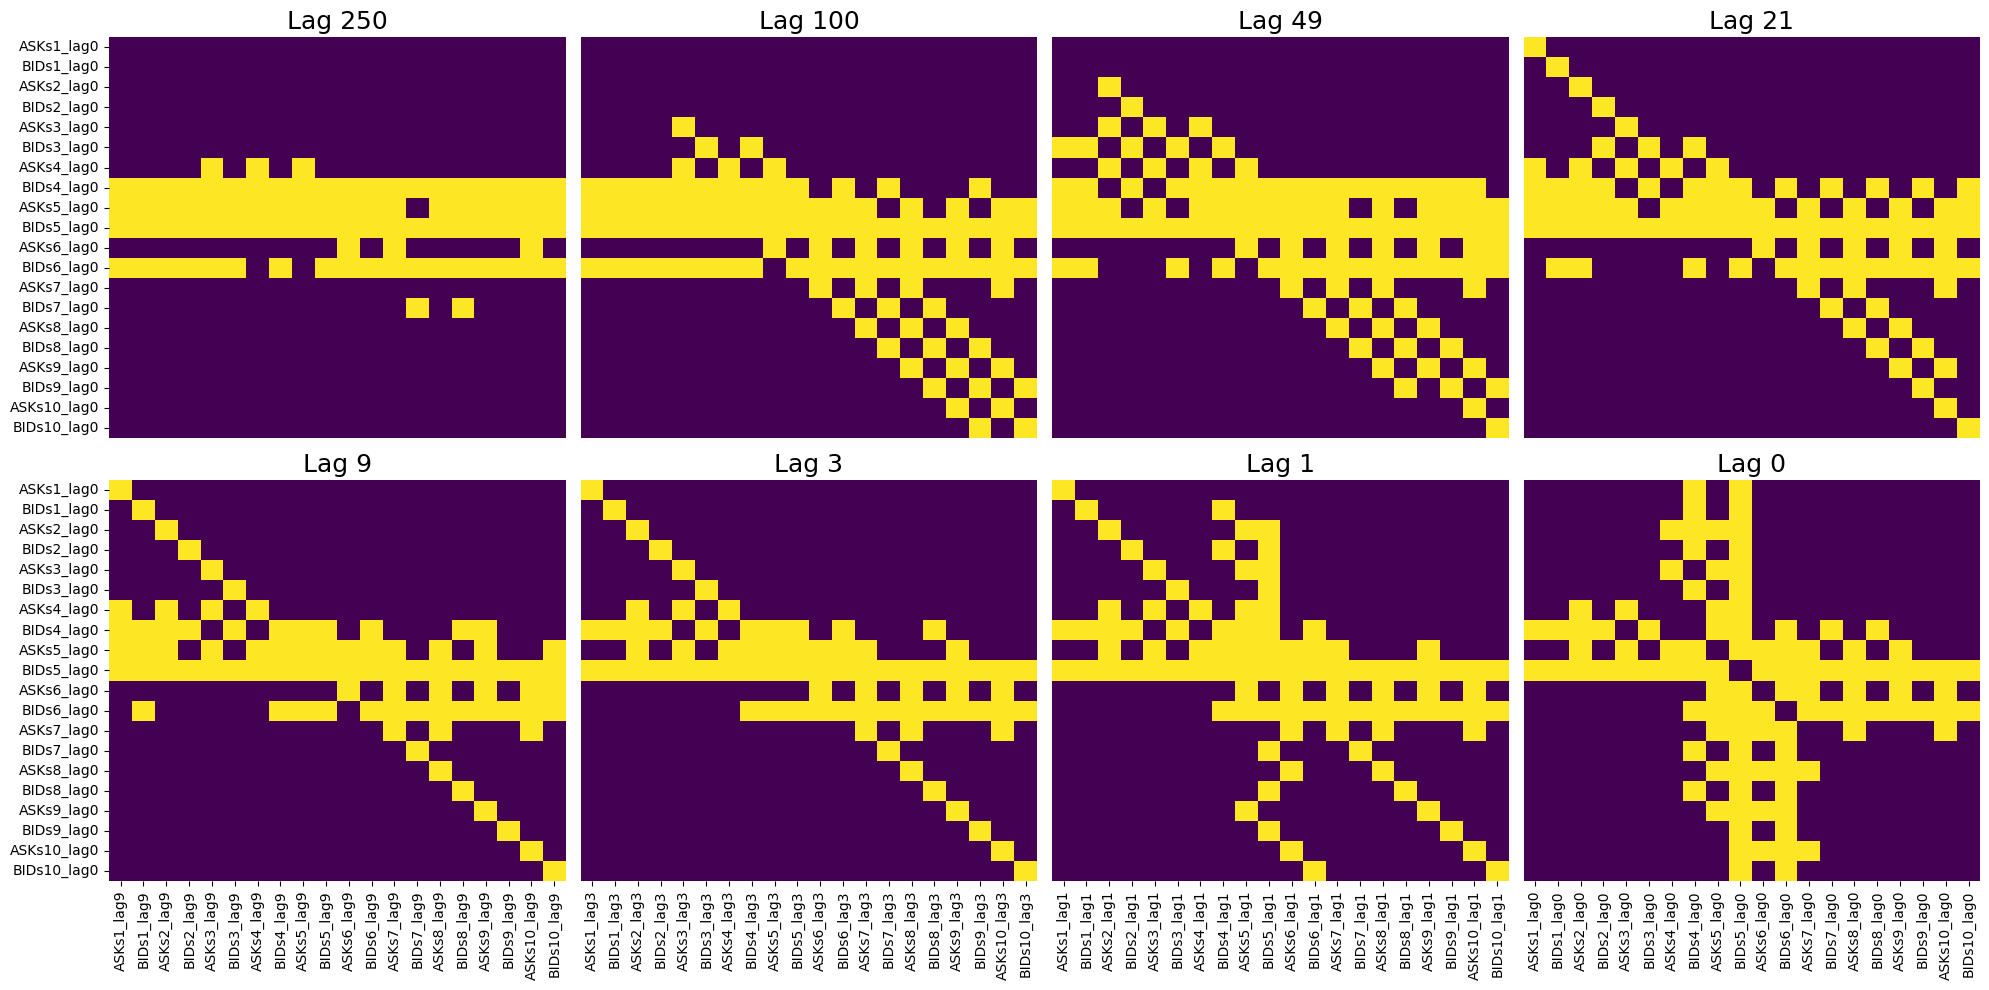

In [4]:
plot_conditional_adjacency_matrices_brief(
    df0, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df1, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df2, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df_final, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)

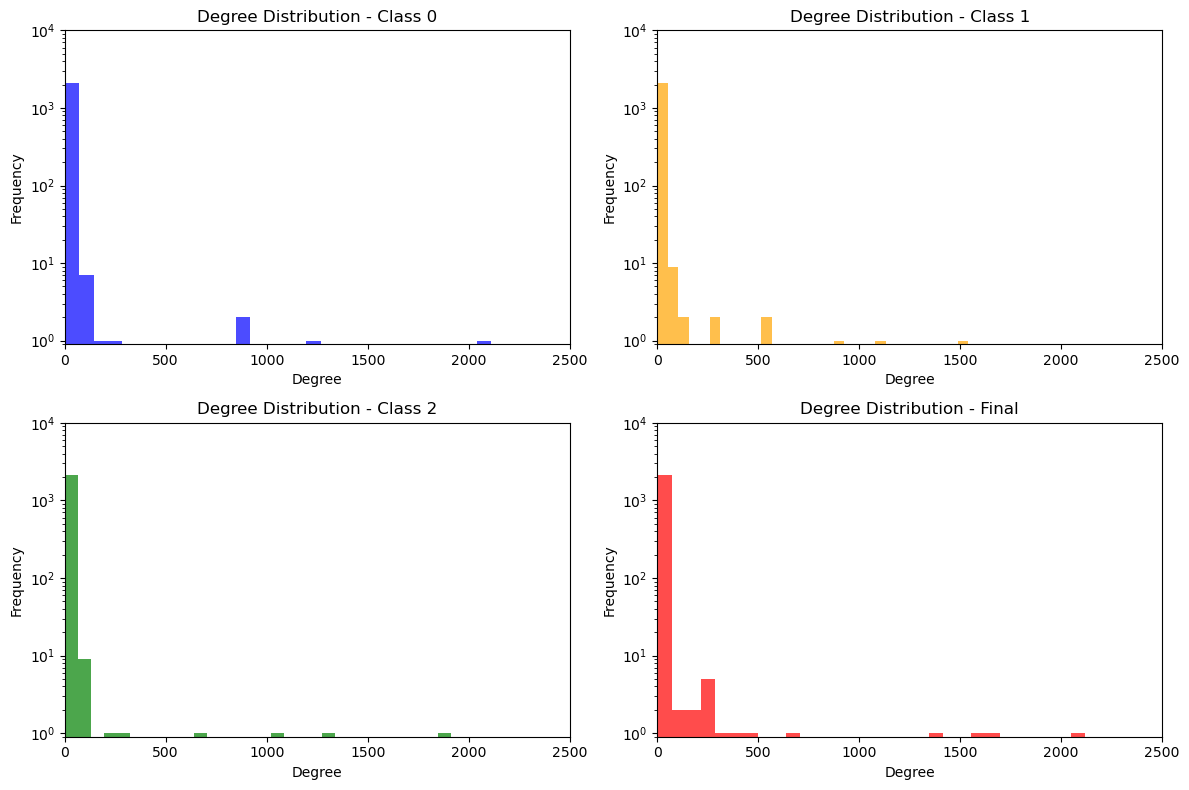

In [5]:
# check degree distribution of each conditional adjacency matrix
degree_distribution0 = np.sum(df0.values != 0, axis=1)
degree_distribution1 = np.sum(df1.values != 0, axis=1)
degree_distribution2 = np.sum(df2.values != 0, axis=1)
degree_distribution_final = np.sum(df_final.values != 0, axis=1)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(degree_distribution0, bins=30, color="blue", alpha=0.7)
plt.title("Degree Distribution - Class 0")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 2)
plt.hist(degree_distribution1, bins=30, color="orange", alpha=0.7)
plt.title("Degree Distribution - Class 1")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 3)
plt.hist(degree_distribution2, bins=30, color="green", alpha=0.7)
plt.title("Degree Distribution - Class 2")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 4)
plt.hist(degree_distribution_final, bins=30, color="red", alpha=0.7)
plt.title("Degree Distribution - Final")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")
plt.tight_layout()
plt.show()

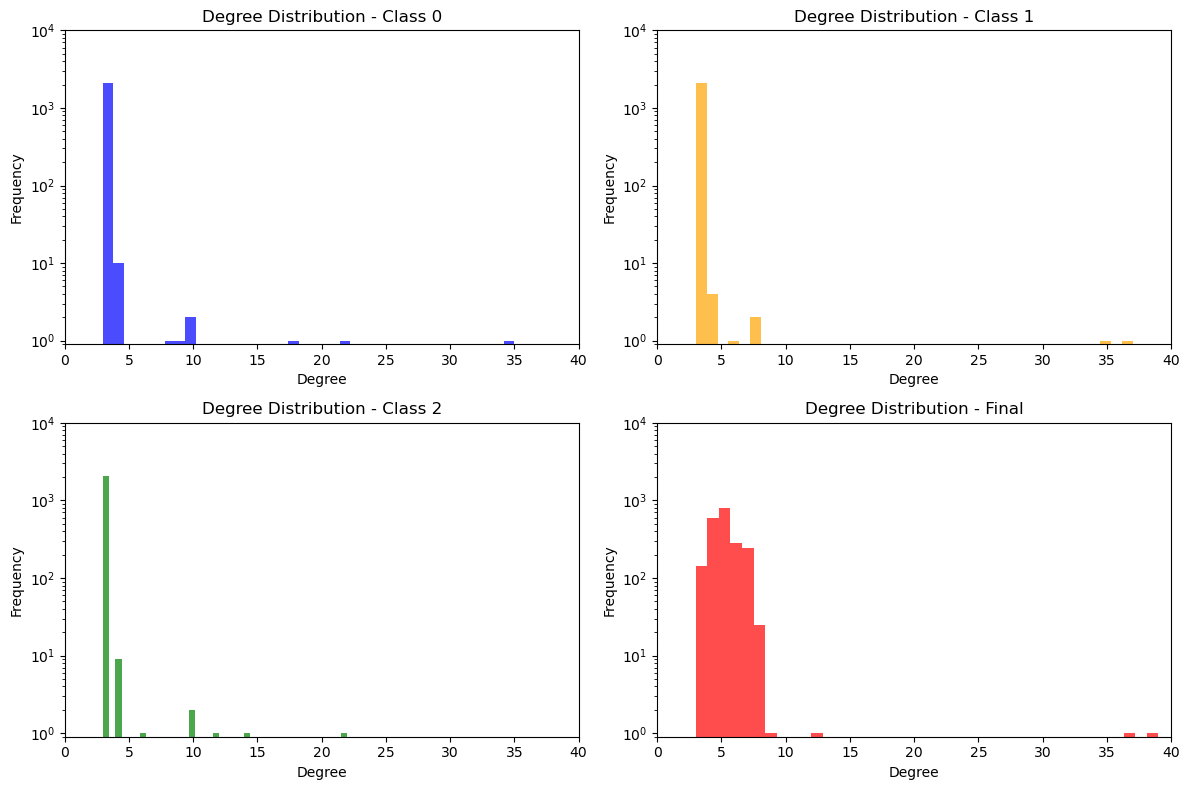

In [6]:
# check degree distribution of each conditional adjacency matrix
degree_distribution0 = np.sum(df0.values != 0, axis=1)
degree_distribution1 = np.sum(df1.values != 0, axis=1)
degree_distribution2 = np.sum(df2.values != 0, axis=1)
degree_distribution_final = np.sum(df_final.values != 0, axis=1)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(
    degree_distribution0[degree_distribution0 < 40], bins=40, color="blue", alpha=0.7
)
plt.title("Degree Distribution - Class 0")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 2)
plt.hist(
    degree_distribution1[degree_distribution1 < 40],
    bins=40,
    color="orange",
    alpha=0.7,
)
plt.title("Degree Distribution - Class 1")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 3)
plt.hist(
    degree_distribution2[degree_distribution2 < 40], bins=40, color="green", alpha=0.7
)
plt.title("Degree Distribution - Class 2")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 4)
plt.hist(
    degree_distribution_final[degree_distribution_final < 40],
    bins=40,
    color="red",
    alpha=0.7,
)
plt.title("Degree Distribution - Final")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")
plt.tight_layout()
plt.show()

In [7]:
# check the number of edges in common between the three conditional adjacency matrices
common_edges_01 = np.sum((df0.values != 0) & (df1.values != 0))
common_edges_02 = np.sum((df0.values != 0) & (df2.values != 0))
common_edges_12 = np.sum((df1.values != 0) & (df2.values != 0))
common_edges_012 = np.sum((df0.values != 0) & (df1.values != 0) & (df2.values != 0))
only_in_01 = np.sum((df0.values != 0) & (df1.values != 0) & (df2.values == 0))
only_in_02 = np.sum((df0.values != 0) & (df2.values != 0) & (df1.values == 0))
only_in_12 = np.sum((df1.values != 0) & (df2.values != 0) & (df0.values == 0))
only_in_0 = np.sum((df0.values != 0) & (df1.values == 0) & (df2.values == 0))
only_in_1 = np.sum((df1.values != 0) & (df0.values == 0) & (df2.values == 0))
only_in_2 = np.sum((df2.values != 0) & (df0.values == 0) & (df1.values == 0))
total_unique_edges = np.sum((df_final.values != 0))
print("Edge Overlap Statistics:")
print(f"Number of common edges between class 0 and class 1: {common_edges_01}")
print(f"Number of common edges between class 0 and class 2: {common_edges_02}")
print(f"Number of common edges between class 1 and class 2: {common_edges_12}")
print(f"Number of common edges between all three classes: {common_edges_012}")
print(f"Number of edges only in class 0 and class 1: {only_in_01}")
print(f"Number of edges only in class 0 and class 2: {only_in_02}")
print(f"Number of edges only in class 1 and class 2: {only_in_12}")
print(f"Number of edges only in class 0: {only_in_0}")
print(f"Number of edges only in class 1: {only_in_1}")
print(f"Number of edges only in class 2: {only_in_2}")
print(f"Total unique edges across all classes: {total_unique_edges}")

Edge Overlap Statistics:
Number of common edges between class 0 and class 1: 7794
Number of common edges between class 0 and class 2: 7530
Number of common edges between class 1 and class 2: 7894
Number of common edges between all three classes: 6156
Number of edges only in class 0 and class 1: 1638
Number of edges only in class 0 and class 2: 1374
Number of edges only in class 1 and class 2: 1738
Number of edges only in class 0: 3540
Number of edges only in class 1: 3176
Number of edges only in class 2: 3440
Total unique edges across all classes: 21062


In [8]:
count_all_cliques(df0)

{1: 2120, 2: 6354, 3: 6352, 4: 2117}

In [9]:
count_all_cliques(df_final)

{1: 2120, 2: 10531, 3: 18775, 4: 15680, 5: 6723, 6: 1564, 7: 158}

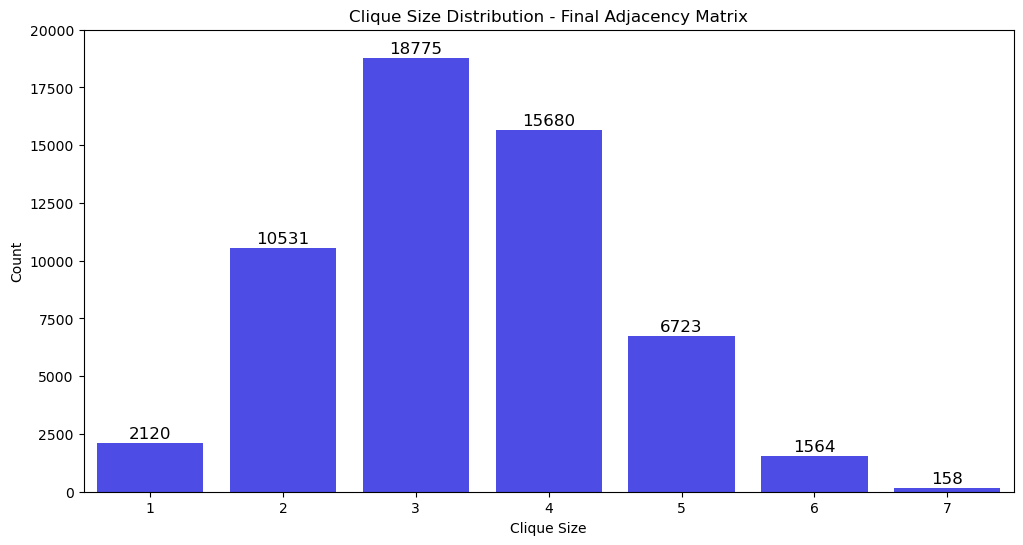

In [10]:
cliques_map = count_all_cliques(df_final)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(cliques_map.keys()),
    y=list(cliques_map.values()),
    color="blue",
    alpha=0.8,
)
# put numbers on top of bars
for i, v in enumerate(cliques_map.values()):
    plt.text(i, v + 200, str(v), ha="center", fontsize=12)

plt.title("Clique Size Distribution - Final Adjacency Matrix")
plt.xlabel("Clique Size")
plt.ylabel("Count")
plt.ylim(0, 20000)
plt.show()

In [13]:
# understand the nodes involved in the biggest cliques
G = nx.from_numpy_array(df_final.values)
cliques = list(nx.find_cliques(G))
max_clique_size = max(len(c) for c in cliques)
biggest_cliques = [c for c in cliques if len(c) == max_clique_size]
nodes_in_biggest_cliques = set()
for clique in biggest_cliques:
    for node in clique:
        nodes_in_biggest_cliques.add(node)
nodes_names = [df_final.index[n] for n in nodes_in_biggest_cliques]
nodes_level = [name.split("s")[1][0] for name in nodes_names]
Counter(nodes_level)

Counter({'8': 94, '7': 64, '6': 3, '5': 2, '9': 1})

In [14]:
# understand nodes with highest degree
degree_series = pd.Series(np.sum(df_final.values != 0, axis=1), index=df_final.index)
top_20_nodes = degree_series.sort_values(ascending=False).head(20)
top_20_nodes

BIDs5_lag0     2119
BIDs6_lag0     1650
ASKs5_lag0     1602
BIDs4_lag0     1400
ASKs6_lag0      656
ASKs4_lag0      443
ASKs7_lag0      384
BIDs3_lag0      328
BIDs7_lag0      282
ASKs9_lag0      253
ASKs8_lag0      252
BIDs8_lag0      252
BIDs9_lag0      248
ASKs3_lag0      188
BIDs10_lag0     155
ASKs10_lag0     136
BIDs2_lag0       87
ASKs2_lag0       73
BIDs1_lag0       39
ASKs1_lag0       37
dtype: int64

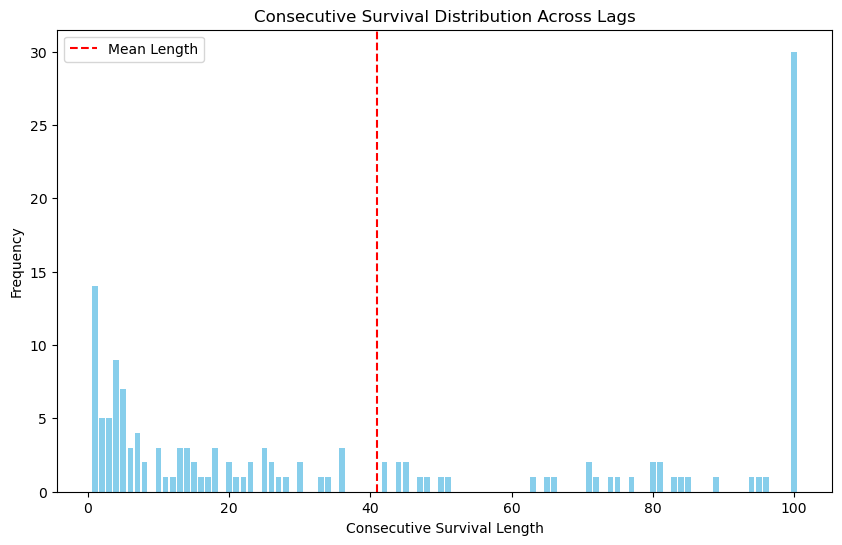

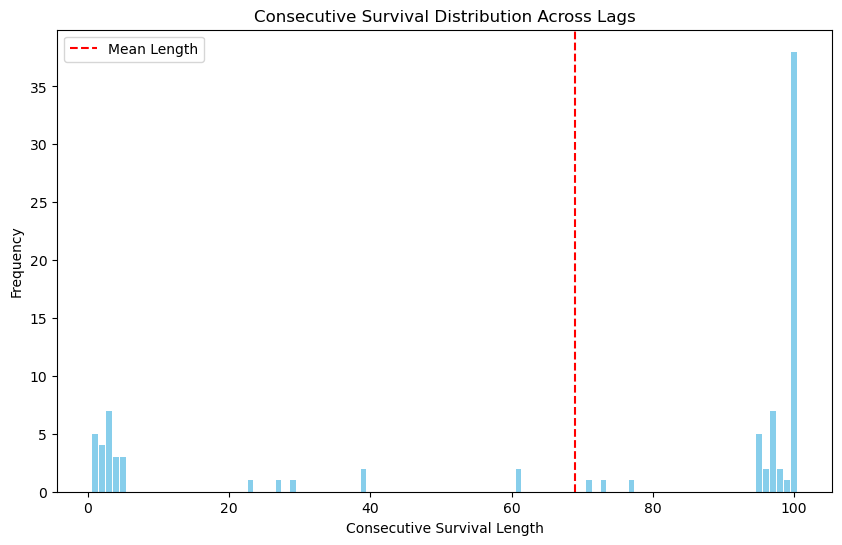

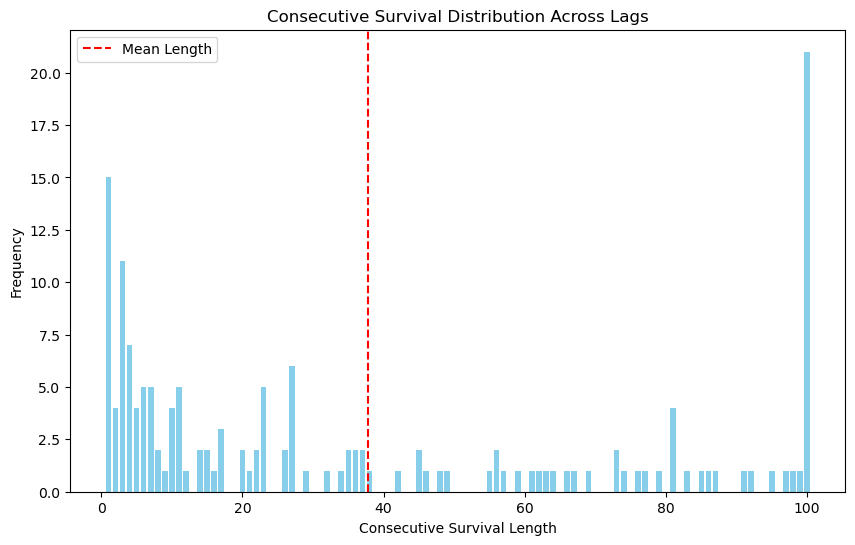

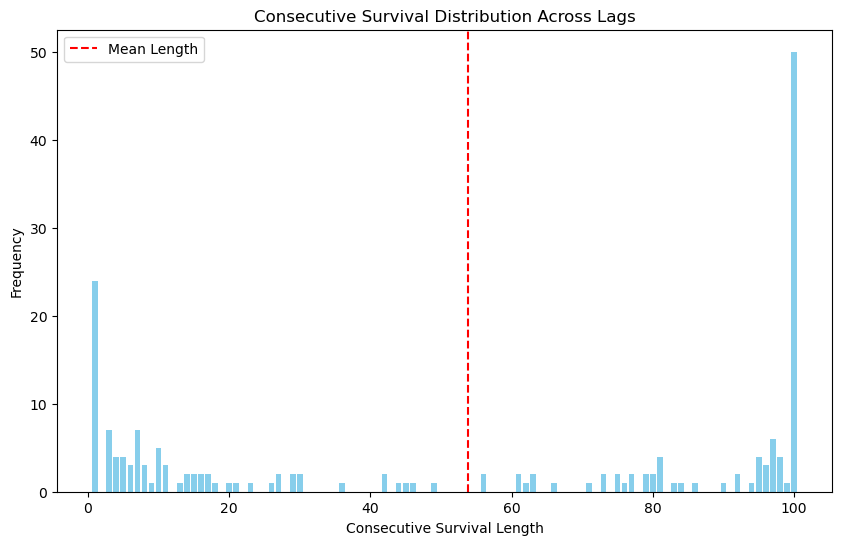

In [85]:
plot_survival_distribution(df0)
plot_survival_distribution(df1)
plot_survival_distribution(df2)
plot_survival_distribution(df_final)

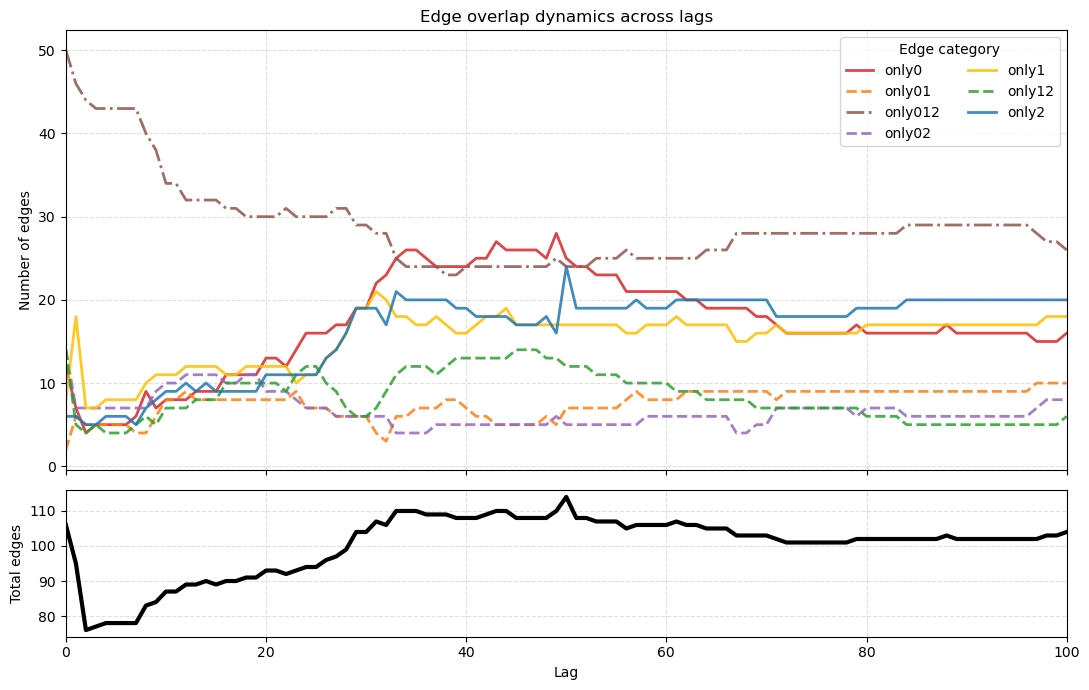

In [86]:
df_overlap_dynamics = overlap_counts_per_lag(df0, df1, df2, lags=range(0, 101))
plot_overlap_dynamics(df_overlap_dynamics)

# OTHER

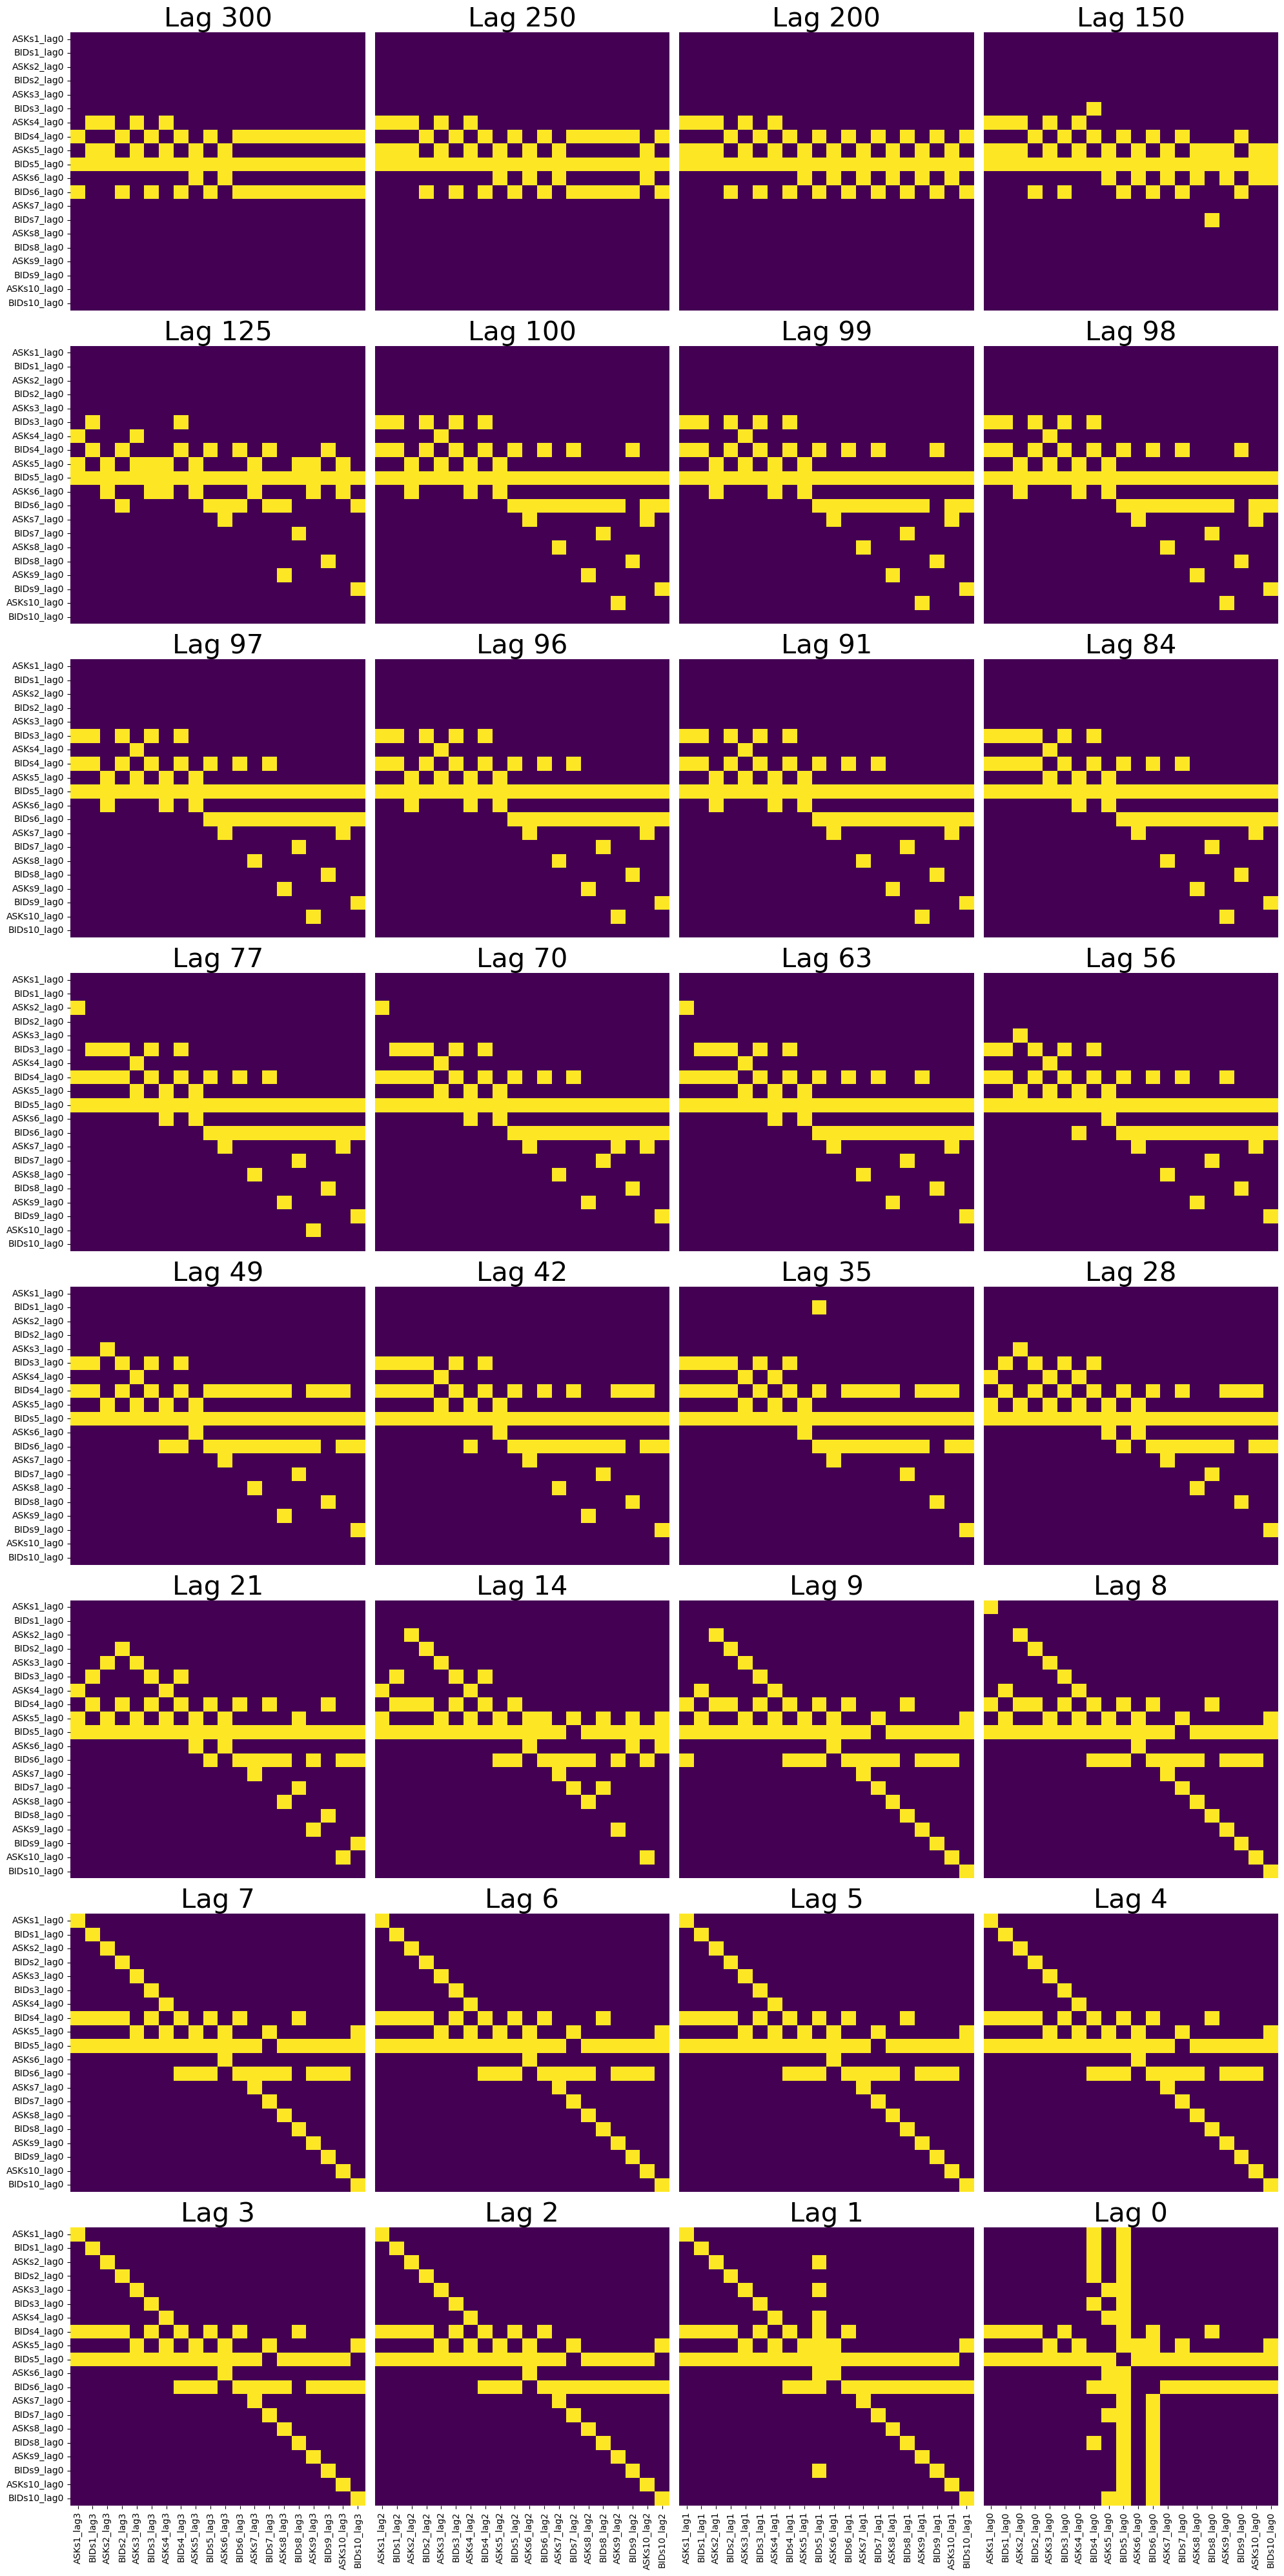

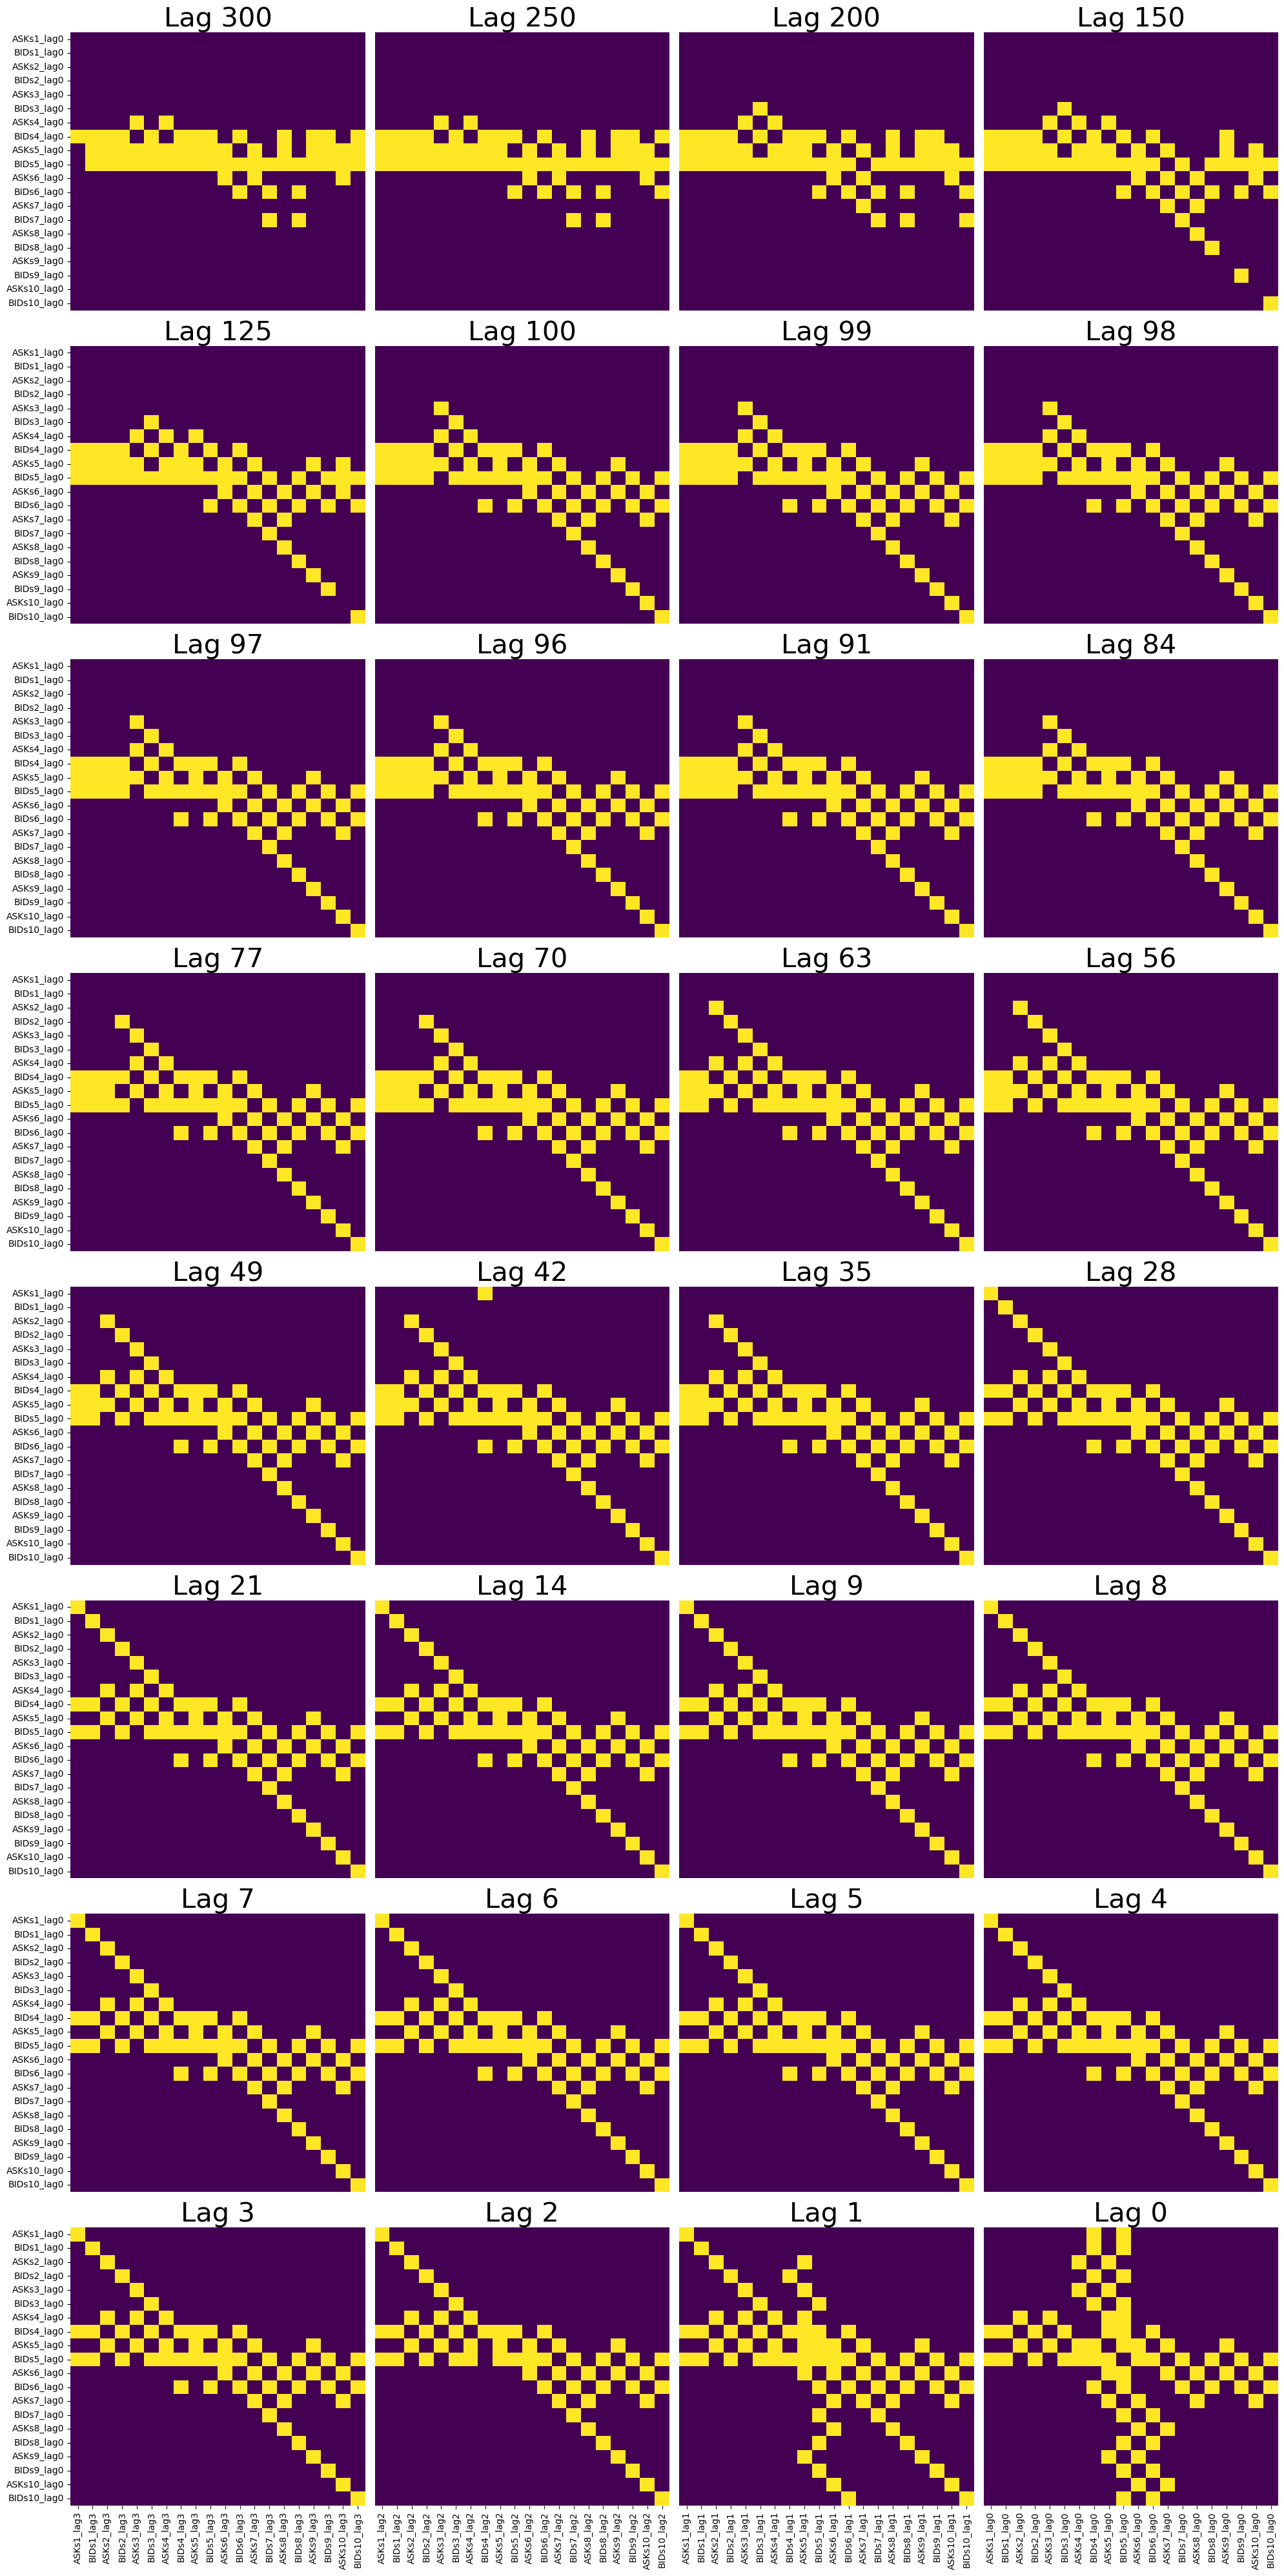

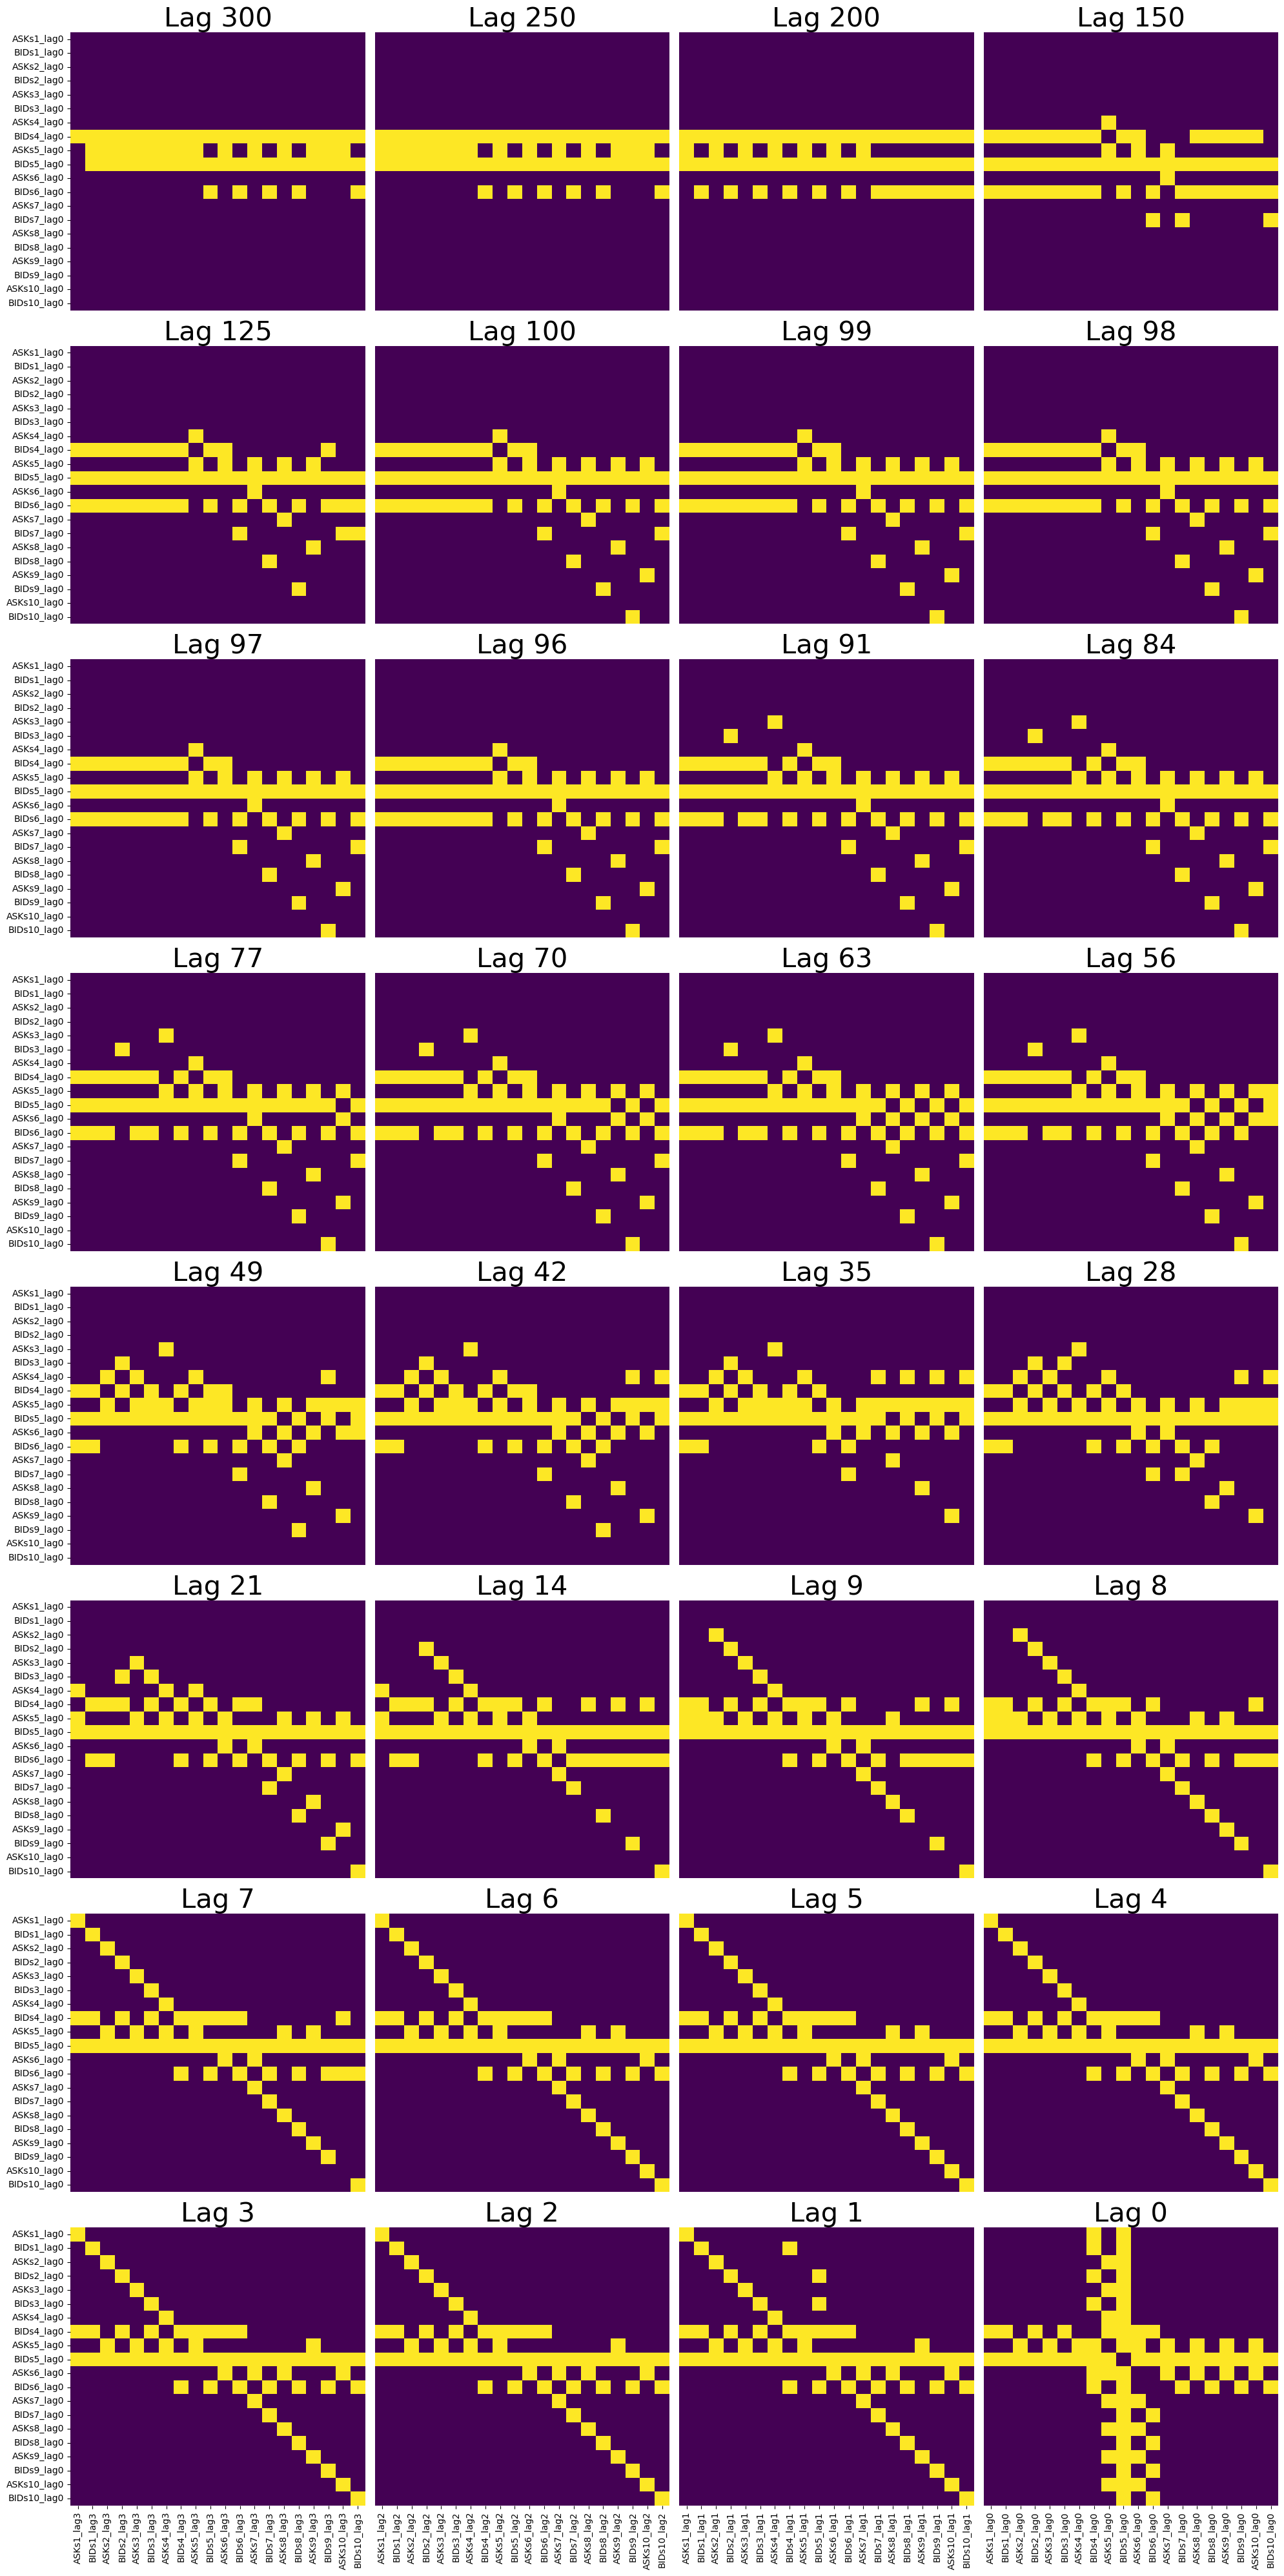

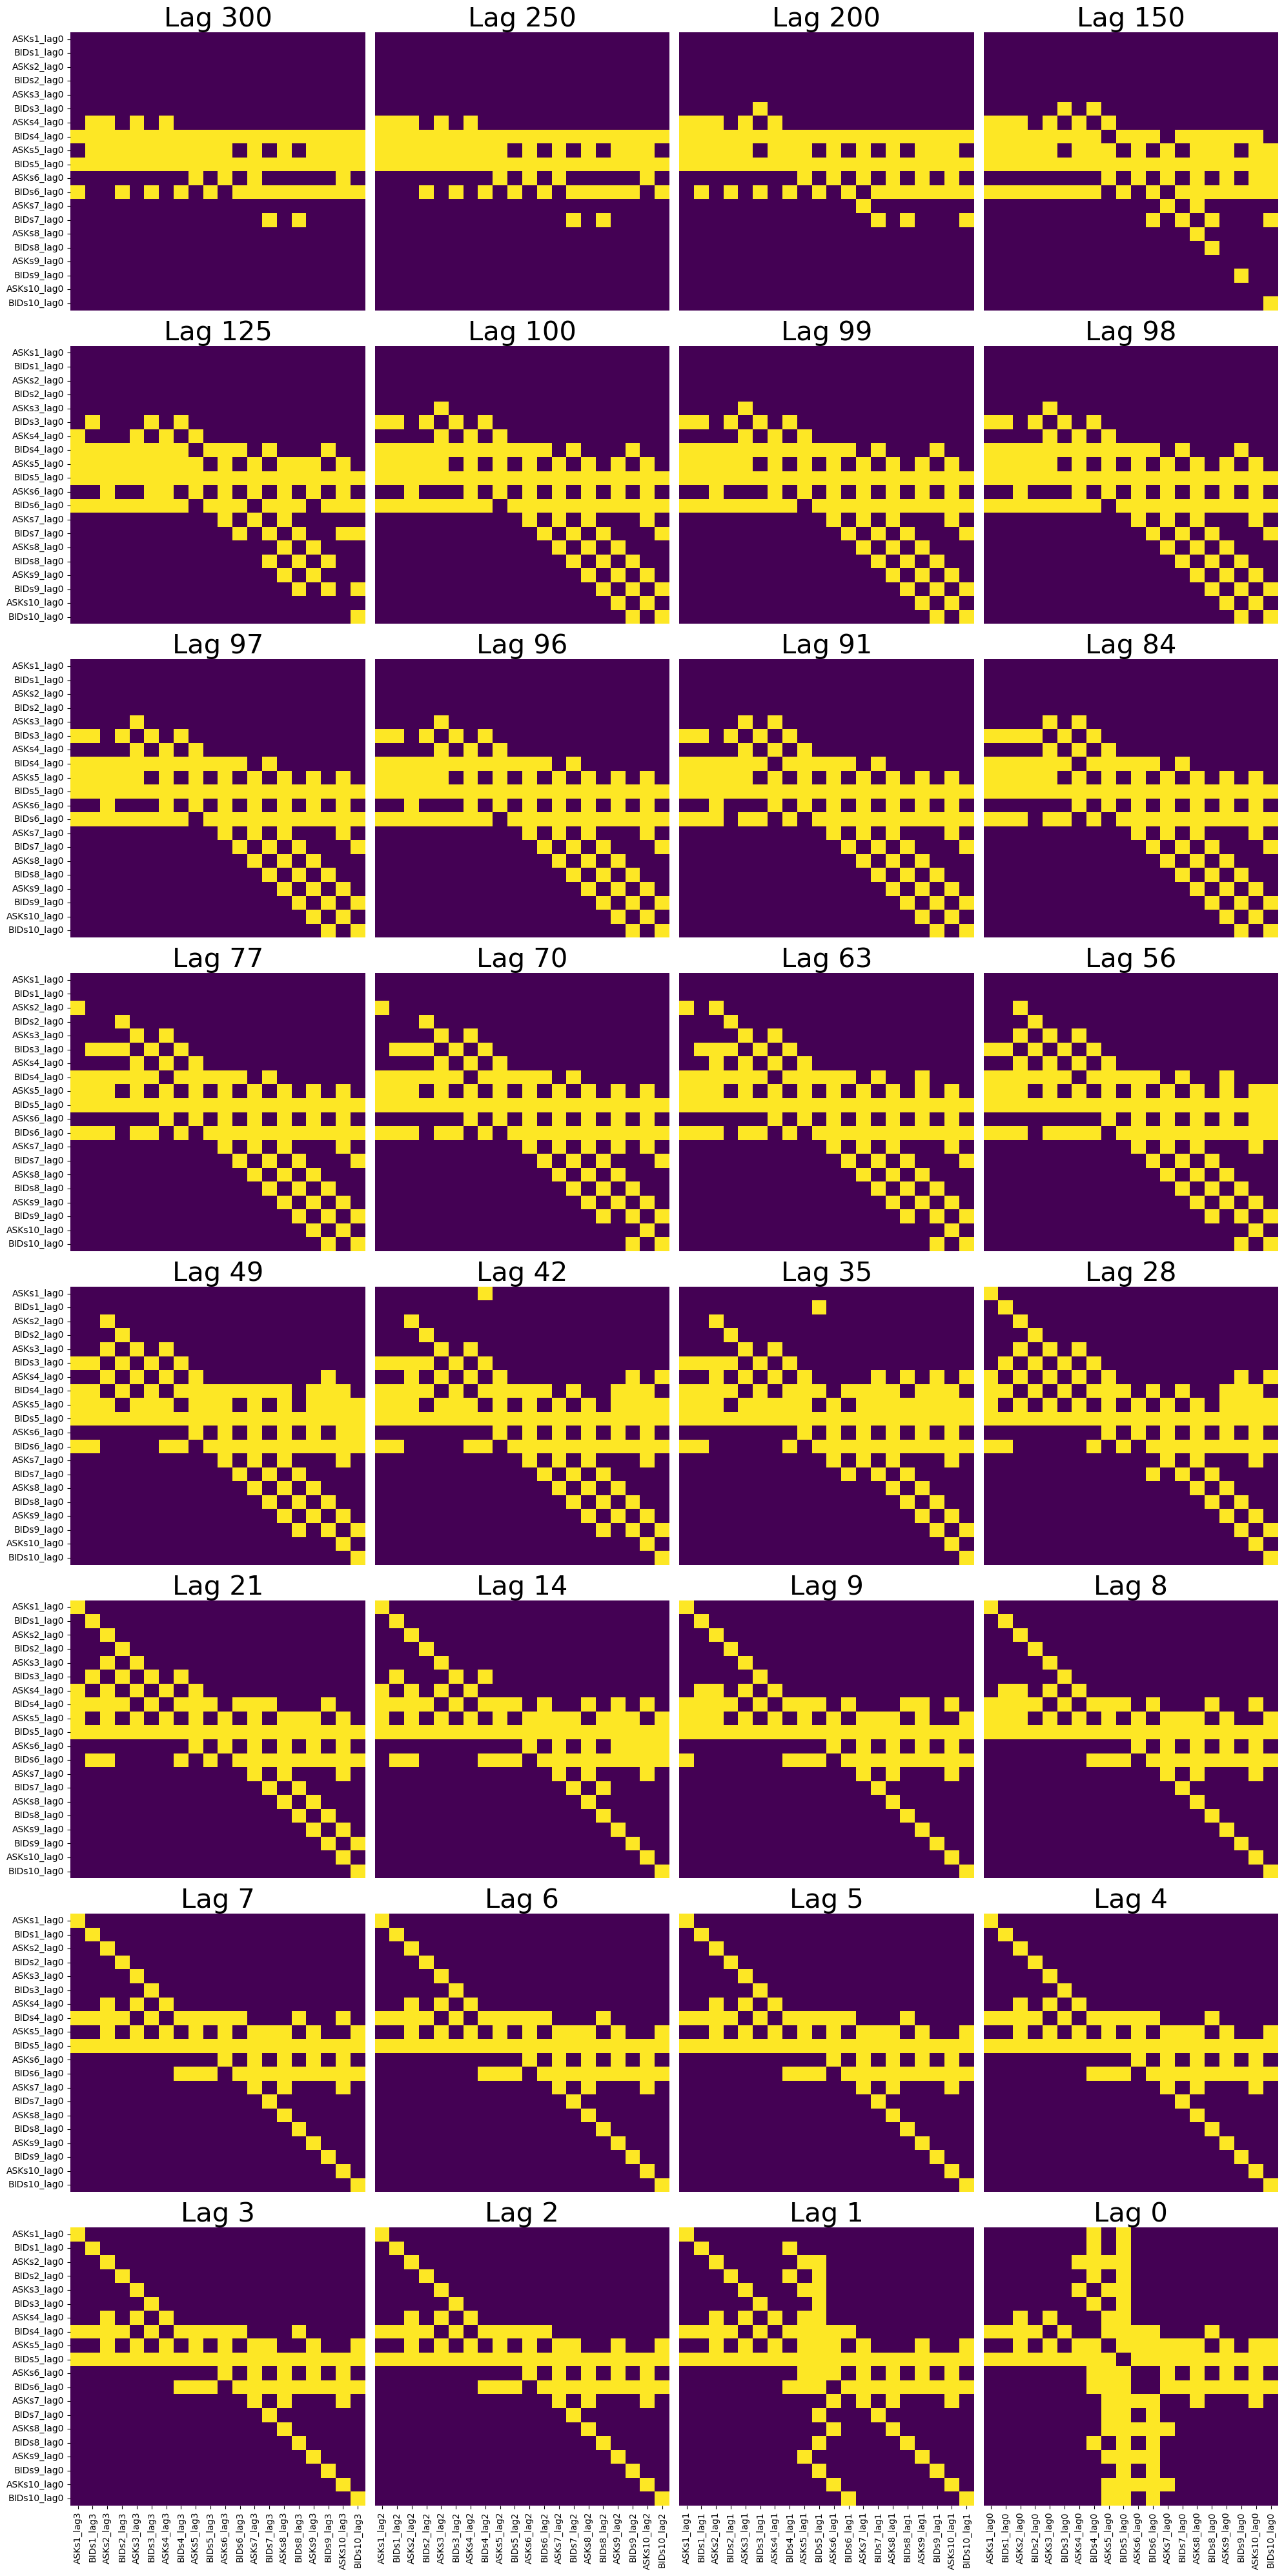

In [87]:
path = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix_min_clique_size1_coordination_number_infinite/final_adjacency_matrix.tsv"
path0 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix_min_clique_size1_coordination_number_infinite/conditional_adjacency_matrix_class_0.tsv"
path1 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix_min_clique_size1_coordination_number_infinite/conditional_adjacency_matrix_class_1.tsv"
path2 = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix_min_clique_size1_coordination_number_infinite/conditional_adjacency_matrix_class_2.tsv"

df_final = pd.read_csv(path, sep="\t", index_col=0)
df0 = pd.read_csv(path0, sep="\t", index_col=0)
df1 = pd.read_csv(path1, sep="\t", index_col=0)
df2 = pd.read_csv(path2, sep="\t", index_col=0)

plot_conditional_adjacency_matrices(df0)
plot_conditional_adjacency_matrices(df1)
plot_conditional_adjacency_matrices(df2)
plot_conditional_adjacency_matrices(df_final)

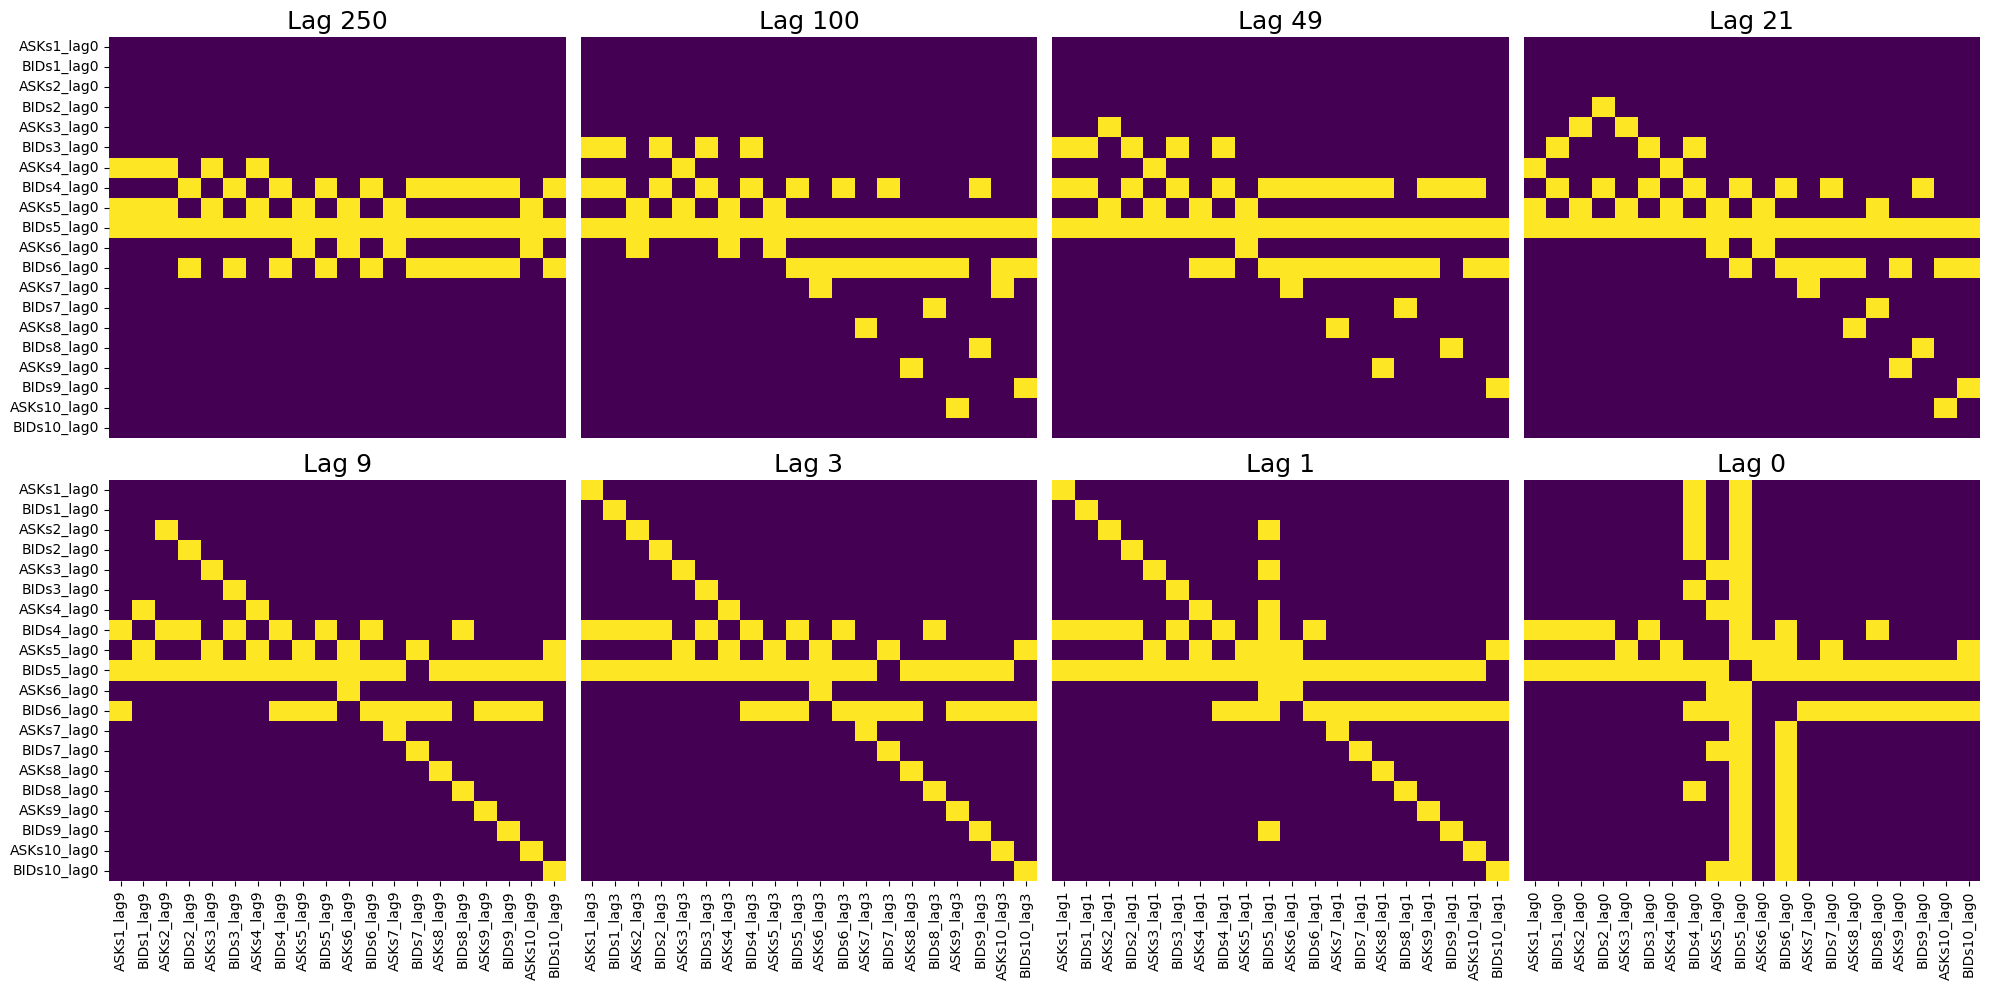

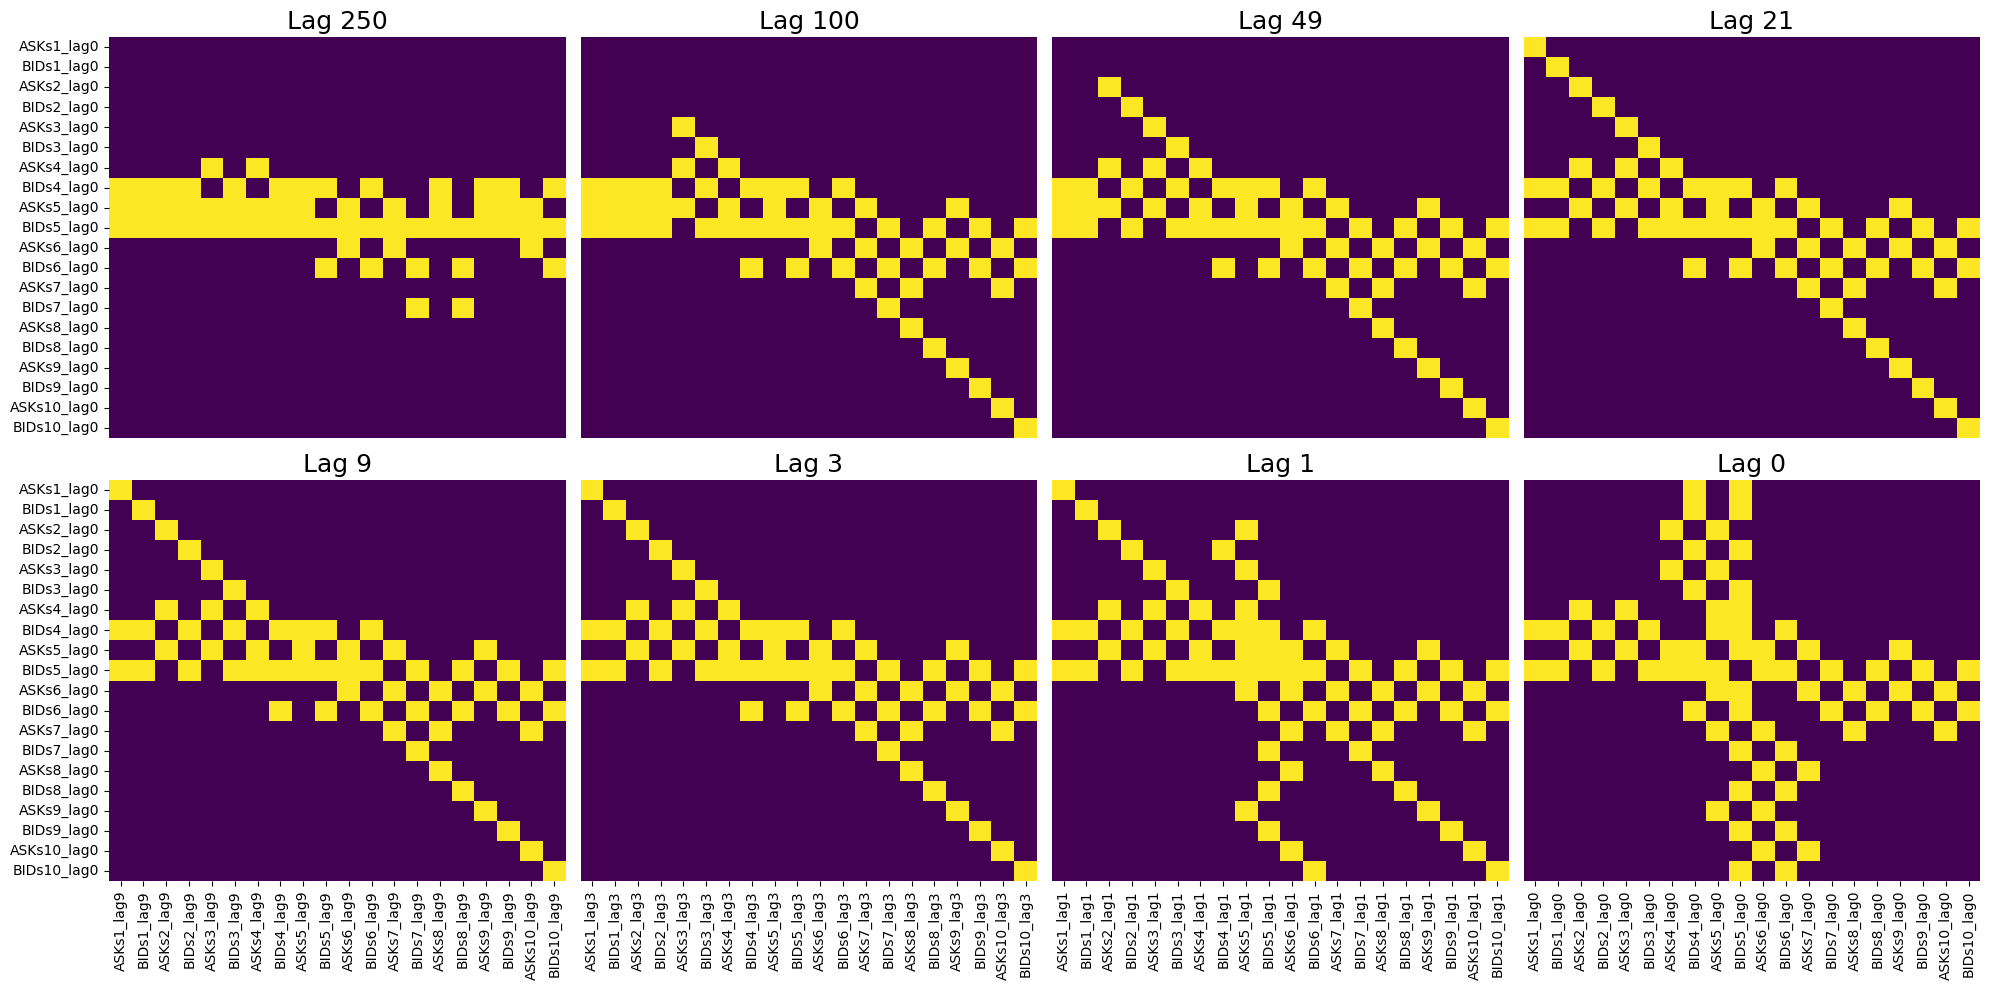

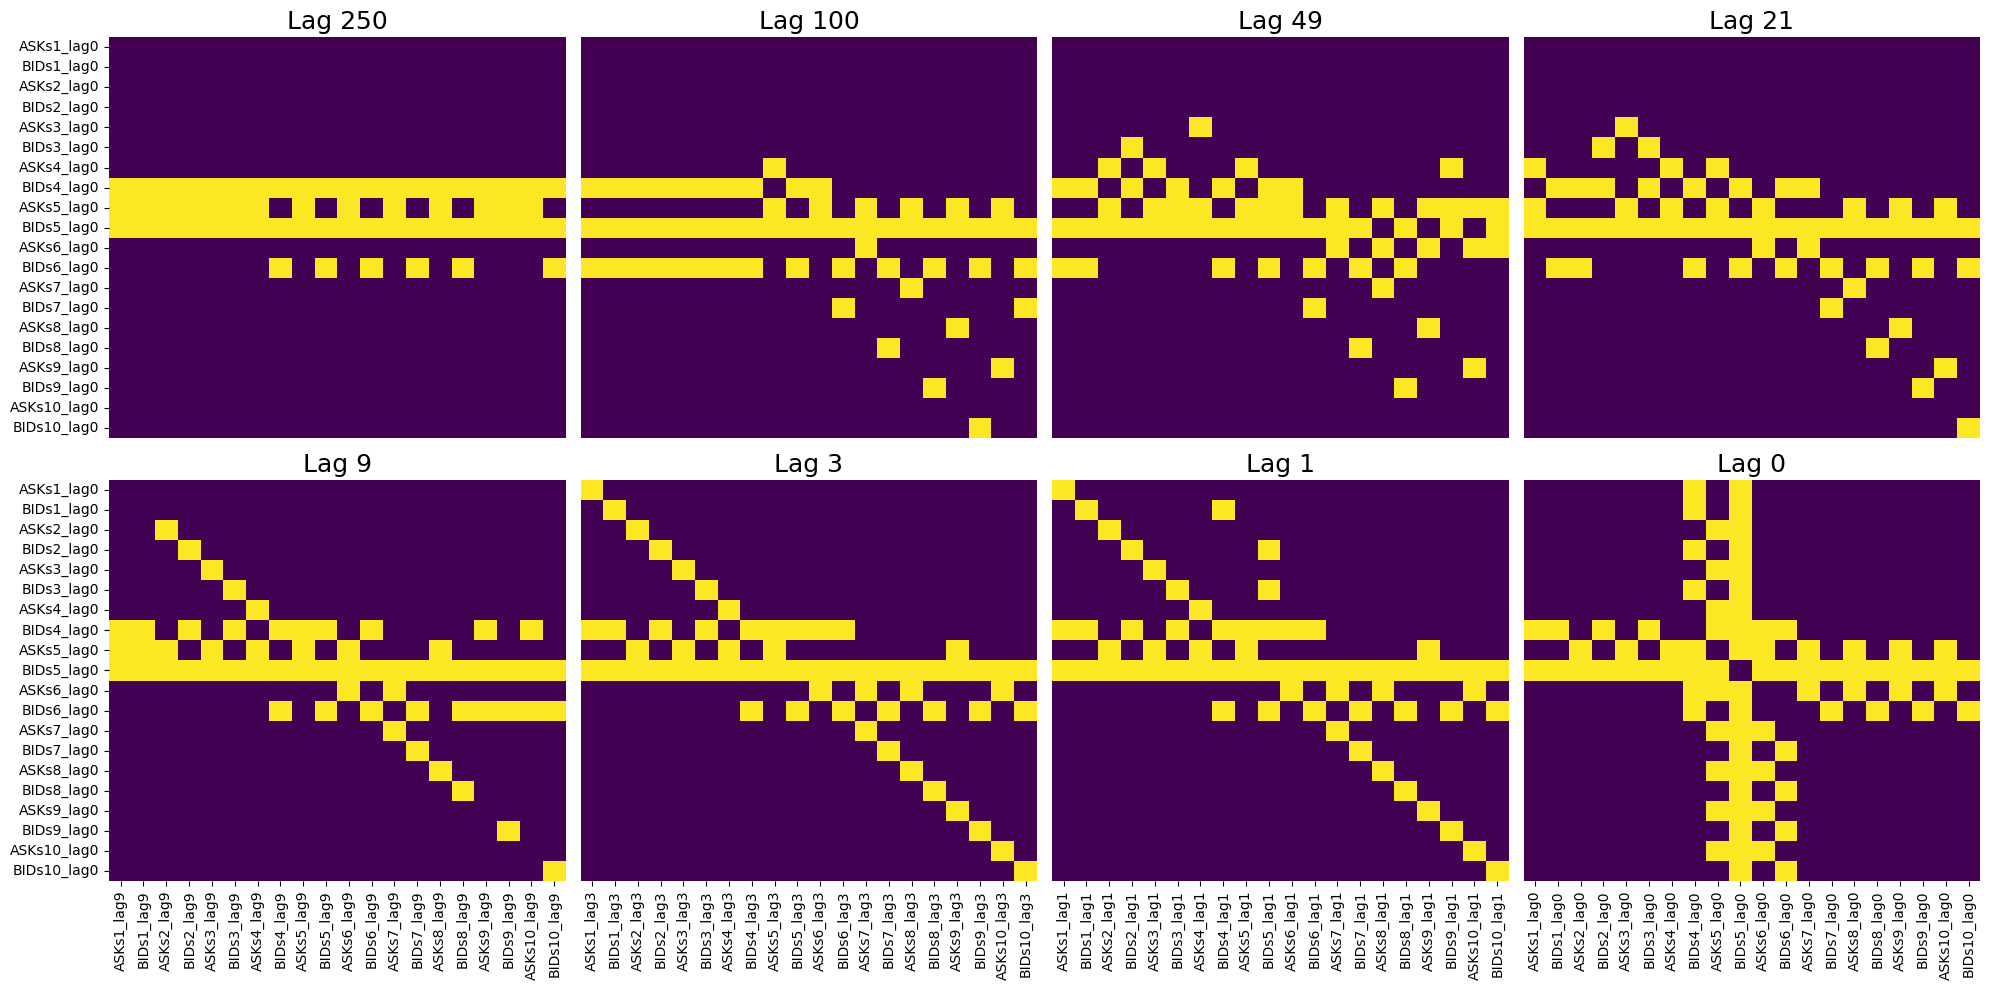

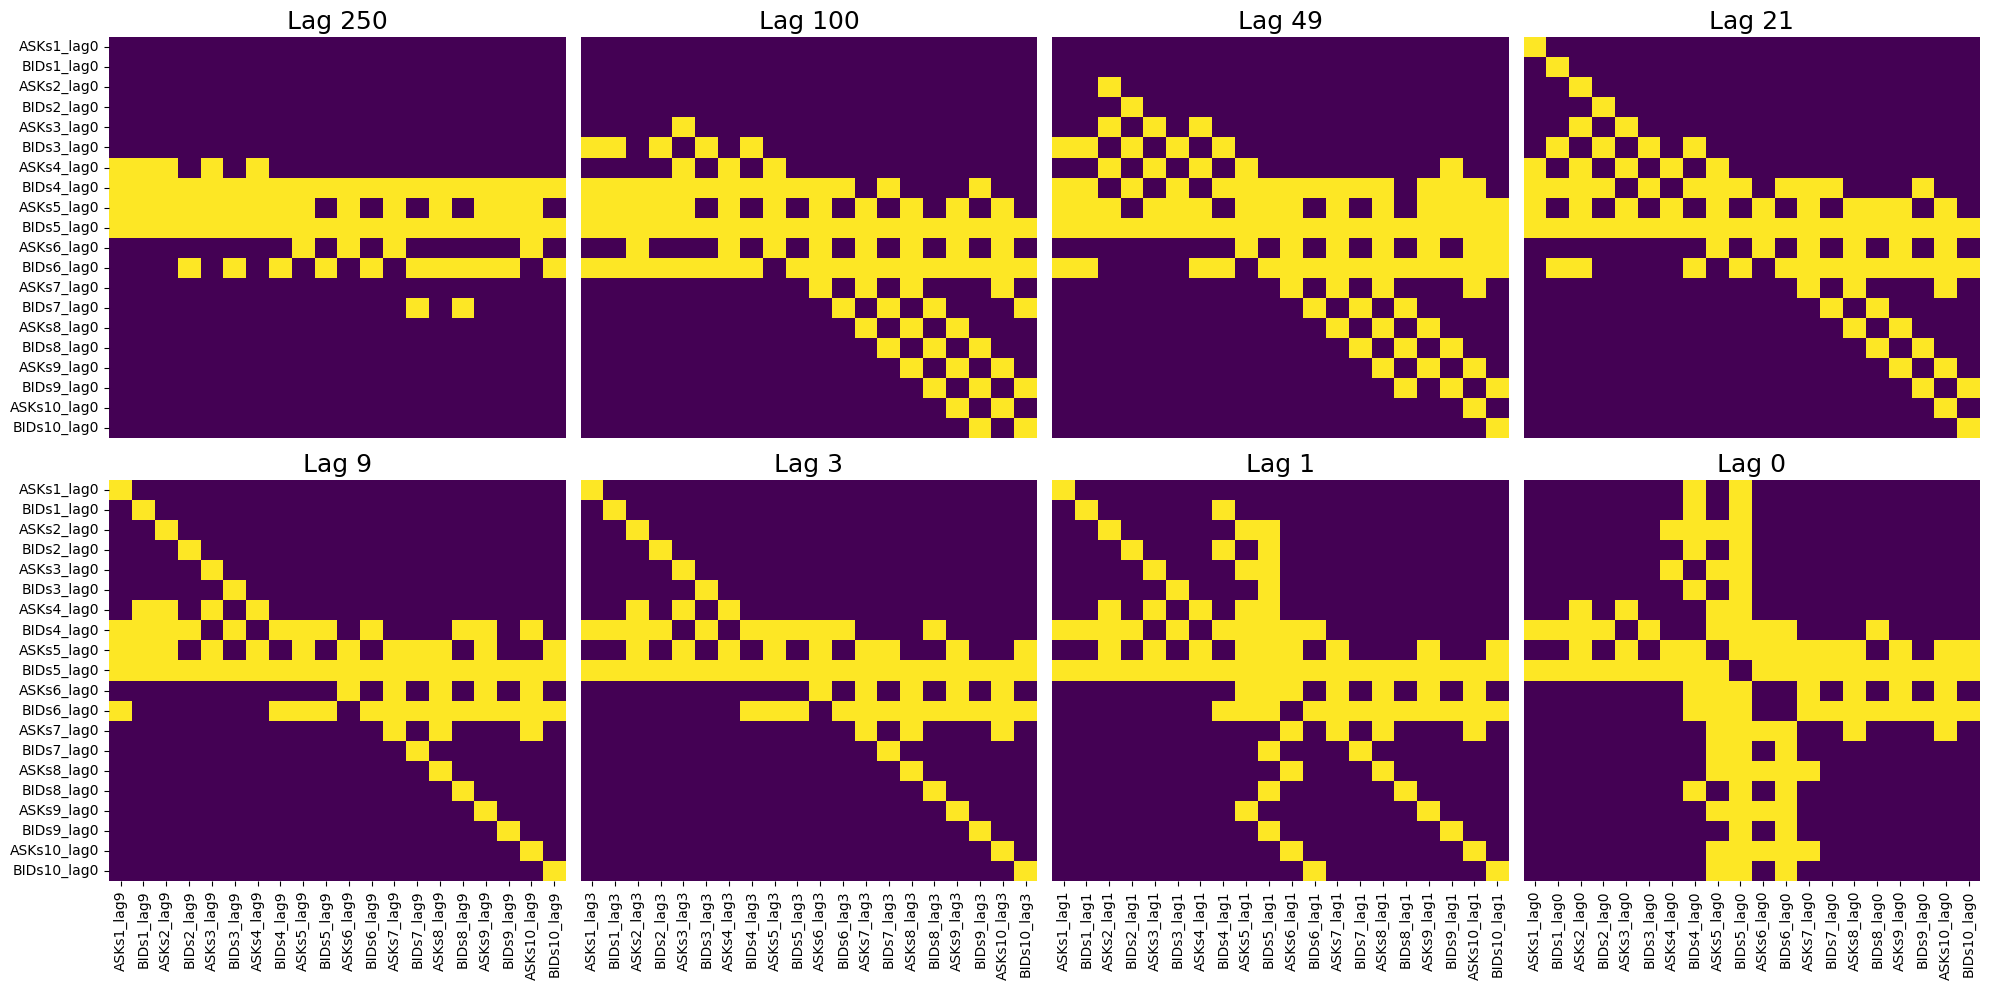

In [88]:
plot_conditional_adjacency_matrices_brief(
    df0, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df1, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df2, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)
plot_conditional_adjacency_matrices_brief(
    df_final, indices=[i + 1 for i in [1, 5, 56, 84, 96, 102, 104, 105]]
)

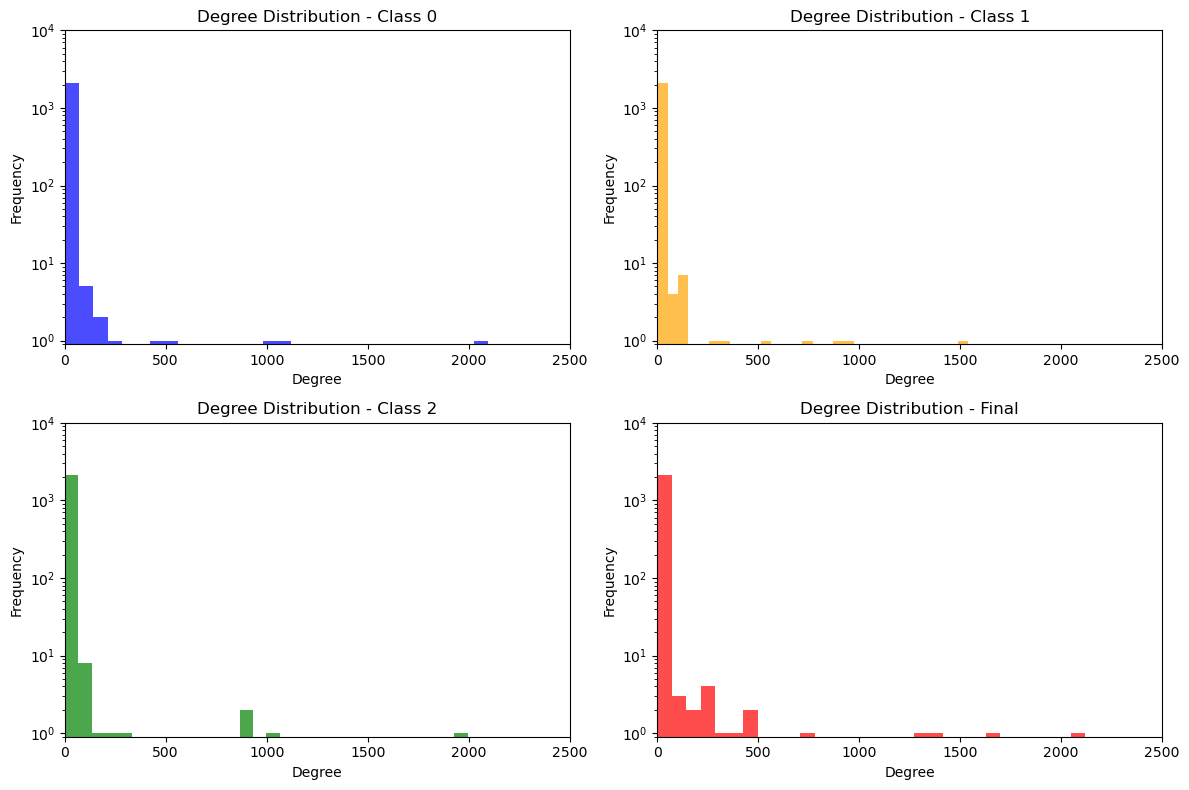

In [89]:
# check degree distribution of each conditional adjacency matrix
degree_distribution0 = np.sum(df0.values != 0, axis=1)
degree_distribution1 = np.sum(df1.values != 0, axis=1)
degree_distribution2 = np.sum(df2.values != 0, axis=1)
degree_distribution_final = np.sum(df_final.values != 0, axis=1)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(degree_distribution0, bins=30, color="blue", alpha=0.7)
plt.title("Degree Distribution - Class 0")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 2)
plt.hist(degree_distribution1, bins=30, color="orange", alpha=0.7)
plt.title("Degree Distribution - Class 1")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 3)
plt.hist(degree_distribution2, bins=30, color="green", alpha=0.7)
plt.title("Degree Distribution - Class 2")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 4)
plt.hist(degree_distribution_final, bins=30, color="red", alpha=0.7)
plt.title("Degree Distribution - Final")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 2500)
plt.ylim(0.9, 10000)
plt.yscale("log")
plt.tight_layout()
plt.show()

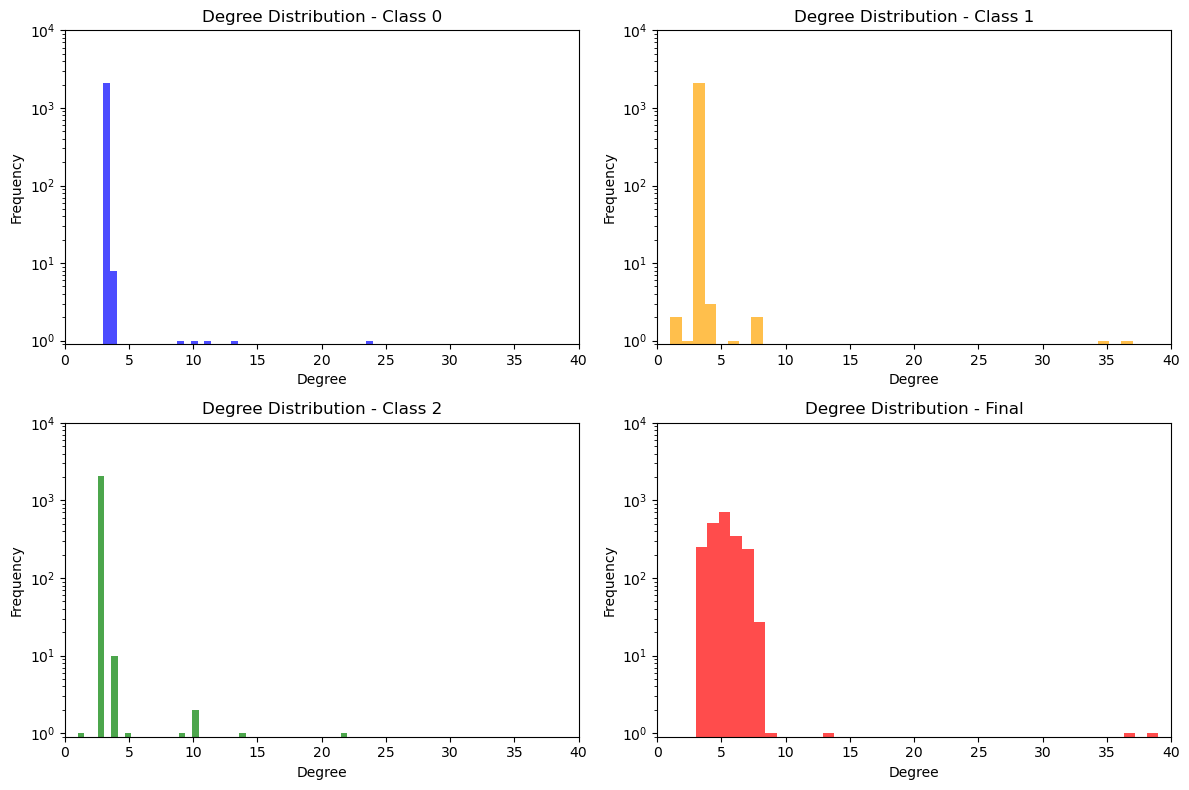

In [90]:
# check degree distribution of each conditional adjacency matrix
degree_distribution0 = np.sum(df0.values != 0, axis=1)
degree_distribution1 = np.sum(df1.values != 0, axis=1)
degree_distribution2 = np.sum(df2.values != 0, axis=1)
degree_distribution_final = np.sum(df_final.values != 0, axis=1)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(
    degree_distribution0[degree_distribution0 < 40], bins=40, color="blue", alpha=0.7
)
plt.title("Degree Distribution - Class 0")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 2)
plt.hist(
    degree_distribution1[degree_distribution1 < 40],
    bins=40,
    color="orange",
    alpha=0.7,
)
plt.title("Degree Distribution - Class 1")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 3)
plt.hist(
    degree_distribution2[degree_distribution2 < 40], bins=40, color="green", alpha=0.7
)
plt.title("Degree Distribution - Class 2")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")

plt.subplot(2, 2, 4)
plt.hist(
    degree_distribution_final[degree_distribution_final < 40],
    bins=40,
    color="red",
    alpha=0.7,
)
plt.title("Degree Distribution - Final")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xlim(0, 40)
plt.ylim(0.9, 10000)
plt.yscale("log")
plt.tight_layout()
plt.show()

In [91]:
# check the number of edges in common between the three conditional adjacency matrices
common_edges_01 = np.sum((df0.values != 0) & (df1.values != 0))
common_edges_02 = np.sum((df0.values != 0) & (df2.values != 0))
common_edges_12 = np.sum((df1.values != 0) & (df2.values != 0))
common_edges_012 = np.sum((df0.values != 0) & (df1.values != 0) & (df2.values != 0))
total_unique_edges = np.sum((df_final.values != 0))
print(f"Number of common edges between class 0 and class 1: {common_edges_01}")
print(f"Number of common edges between class 0 and class 2: {common_edges_02}")
print(f"Number of common edges between class 1 and class 2: {common_edges_12}")
print(f"Number of common edges between all three classes: {common_edges_012}")
print(f"Total unique edges across all classes: {total_unique_edges}")

Number of common edges between class 0 and class 1: 7524
Number of common edges between class 0 and class 2: 7750
Number of common edges between class 1 and class 2: 8390
Number of common edges between all three classes: 6480
Total unique edges across all classes: 20924


In [92]:
print(count_all_cliques(df0), count_all_cliques(df_final))

{1: 2120, 2: 6354, 3: 6352, 4: 2117} {1: 2120, 2: 10462, 3: 18155, 4: 13858, 5: 4524, 6: 478}


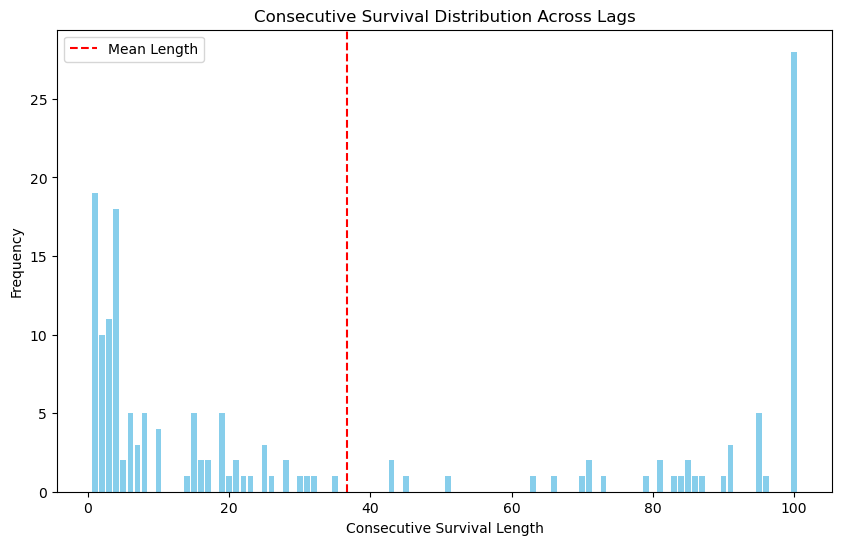

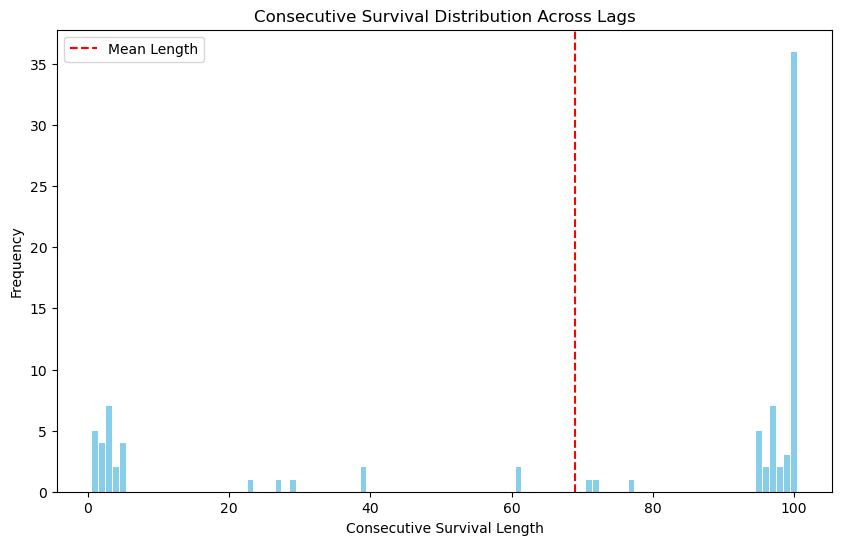

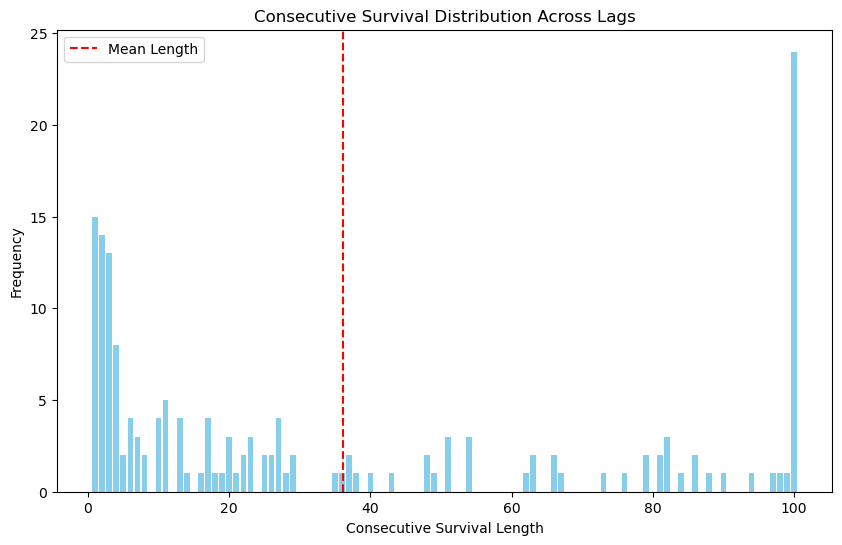

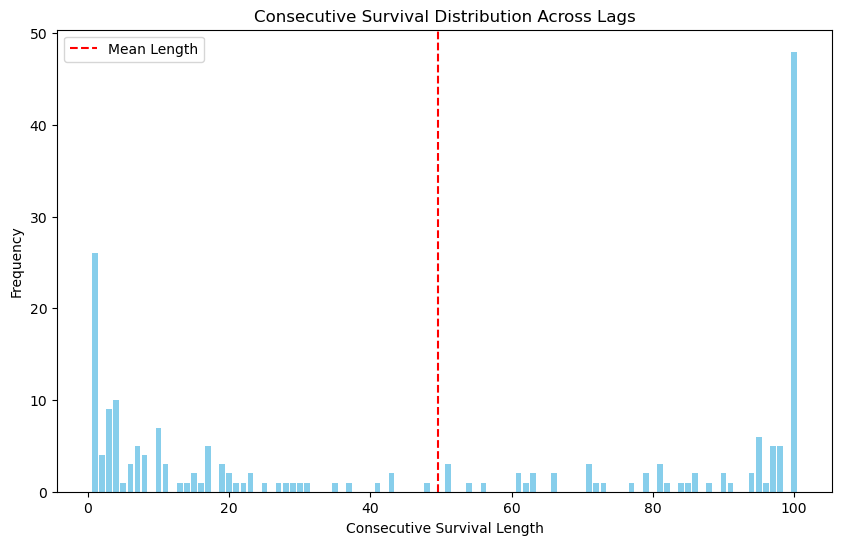

In [93]:
plot_survival_distribution(df0)
plot_survival_distribution(df1)
plot_survival_distribution(df2)
plot_survival_distribution(df_final)

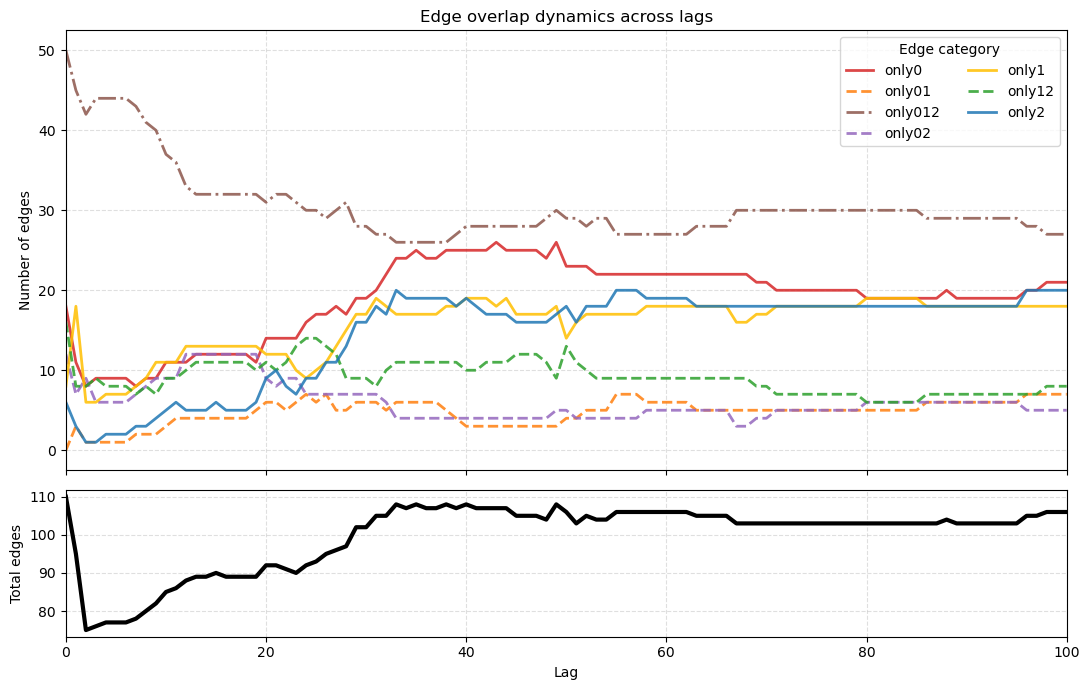

In [94]:
df_overlap_dynamics = overlap_counts_per_lag(df0, df1, df2, lags=range(0, 101))
plot_overlap_dynamics(df_overlap_dynamics)

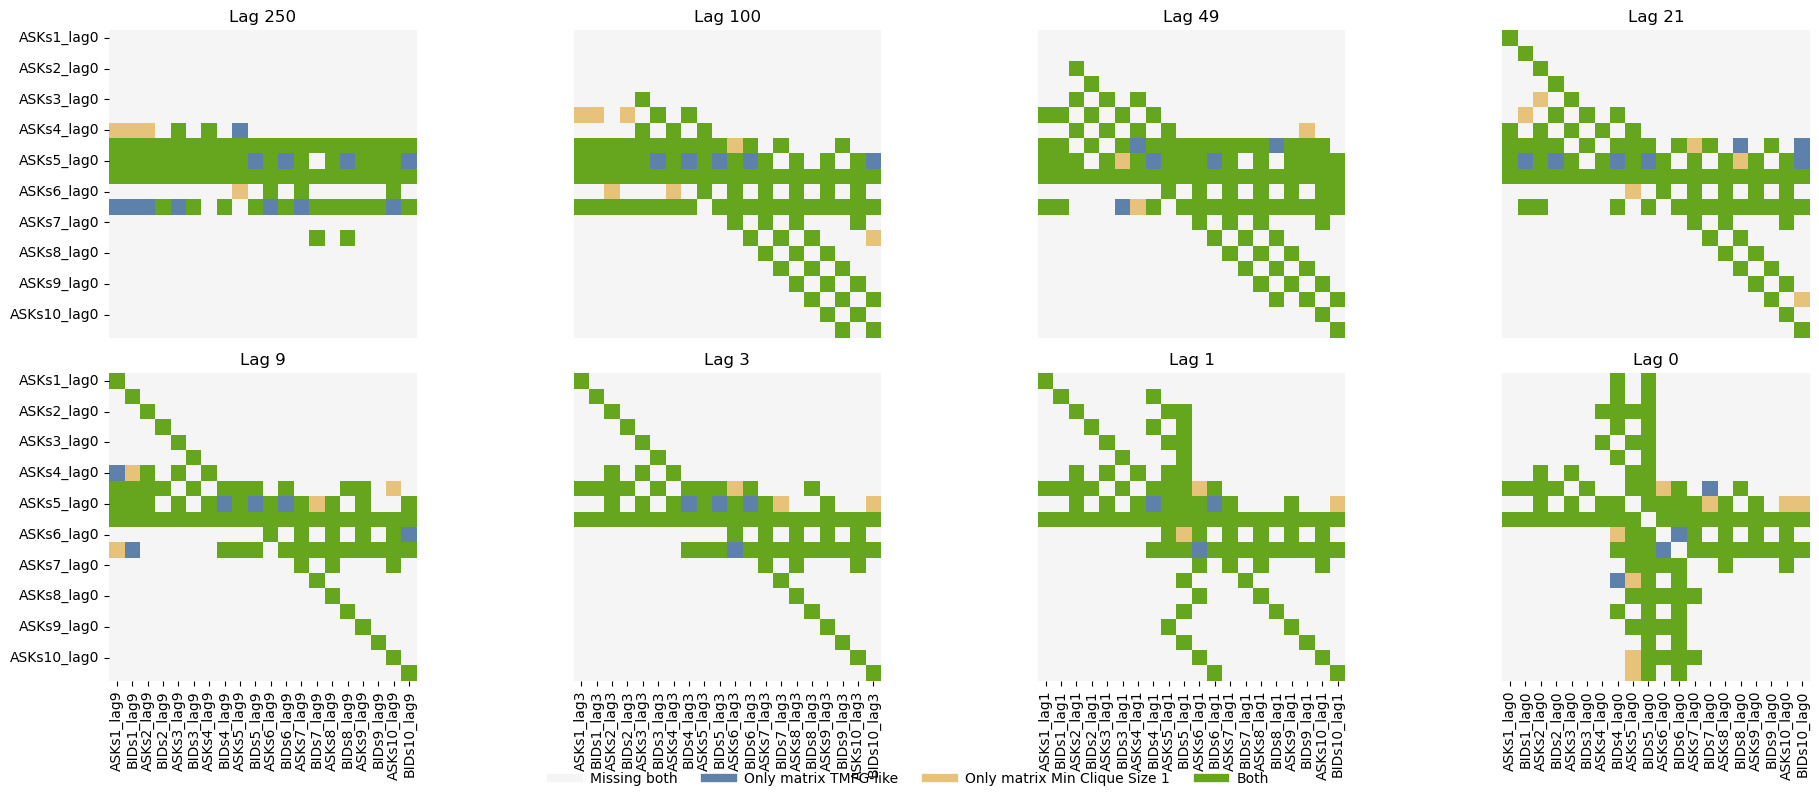

In [114]:
selected_lags = sorted([0, 1, 3, 9, 21, 49, 100, 250], reverse=True)

tmfg_like_path = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix/final_adjacency_matrix.tsv"
mfcf_path = "/home/daxus/code/LOBFrame/spatiotemporal_folder/CSCO/conditional_networks/adjacency_matrix_min_clique_size1_coordination_number_infinite/final_adjacency_matrix.tsv"

adjacency_matrix_1 = pd.read_csv(tmfg_like_path, sep="\t", index_col=0)
adjacency_matrix_2 = pd.read_csv(mfcf_path, sep="\t", index_col=0)

plot_lag_comparison_grid(
    A1_big=adjacency_matrix_1,
    A2_big=adjacency_matrix_2,
    lags=selected_lags,
)